## Models

Models can be utilized in two ways:

    With agents - Models can be dynamically specified when creating an agent.
    Standalone - Models can be called directly (outside of the agent loop) for tasks like text generation, classification, or extraction without the need for an agent framework.

The same model interface works in both contexts, which gives you the flexibility to start simple and scale up to more complex agent-based workflows as needed.

### Initialize a model

The easiest way to get started with a standalone model in LangChain is to use init_chat_model to initialize one from a chat model provider of your choice (examples below):

` import os `
` from langchain.chat_models import init_chat_model `

` os.environ["OPENAI_API_KEY"] = "sk-..."`

` model = init_chat_model("gpt-5.4")`

In [2]:
import os
from langchain.chat_models import init_chat_model

os.environ["OPENAI_API_KEY"] = "sk-..."

model = init_chat_model("gpt-5.4")

In [3]:
import os
from langchain.chat_models import init_chat_model
model = init_chat_model(
    "auto",
    model_provider="openrouter",
    # Kwargs passed to the model:
    temperature=0.7,
    timeout=30,
    max_tokens=1000,
    max_retries=6,  # Default; increase for unreliable networks
)

In [4]:
response = model.invoke("Why do parrots talk?")
print(response.content)

KeyboardInterrupt: 

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    max_retries=10,  # Increase for unreliable networks (default: 6)
    timeout=120,  # Seconds; increase for slow connections
)

In [ ]:
response = model.invoke("Why do parrots talk?")
print(response.content)

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2 seconds as it raised ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite
Please retry in 55.447532364s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash-lite"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
,

KeyboardInterrupt: 

### Invocation

The most straightforward way to call a model is to use invoke() with a single message or a list of messages.


In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model="gpt-5-nano",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
)

In [ ]:
conversation = [
    {"role": "system", "content": "You are a helpful assistant that translates English to French."},
    {"role": "user", "content": "Translate: I love programming."},
    {"role": "assistant", "content": "J'adore la programmation."},
    {"role": "user", "content": "Translate: I love building applications."}
]

response = model.invoke(conversation)
print(response) 

content="J'adore créer des applications." additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019e3eb8-572c-7952-8588-3d4ce76a8cec-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 34, 'output_tokens': 7, 'total_tokens': 41, 'input_token_details': {'cache_read': 0}}


In [ ]:
from langchain.messages import HumanMessage, AIMessage, SystemMessage

conversation = [
    SystemMessage("You are a helpful assistant that translates English to French."),
    HumanMessage("Translate: I love programming."),
    AIMessage("J'adore la programmation."),
    HumanMessage("Translate: I love building applications.")
]

response = model.invoke(conversation)
print(response)

content="J'adore créer des applications." additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019e3eb8-6125-7bb0-b236-c5a2471113f9-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 34, 'output_tokens': 7, 'total_tokens': 41, 'input_token_details': {'cache_read': 0}}


### Stream

Most models can stream their output content while it is being generated. By displaying output progressively, streaming significantly improves user experience, particularly for longer responses.

In [ ]:
for chunk in model.stream("Why do parrots have colorful feathers?"):
    print(chunk.text, end="|", flush=True)

Parrots have| colorful feathers for a variety of fascinating reasons, primarily related to **survival and reproduction**. Here's a| breakdown of the key factors:

**1. Communication and Social Signaling:**

* **Mate Attraction:** This is arguably the most significant reason. Bright, vibrant colors are often a sign of good health, a strong immune system, and good genes|. Potential mates are more likely to be attracted to individuals with striking plumage, as they are perceived as more desirable and likely to produce healthy offspring.
* **Species Recognition:** In dense rainforests where visual cues can be challenging, distinct color| patterns help parrots identify members of their own species. This is crucial for finding mates, forming flocks, and avoiding interbreeding.
* **Social Status and Dominance:** Certain color patterns or the intensity of colors can signal an individual's social rank| within a flock. This can help reduce aggression and establish a pecking order.
* **Mood and E

In [ ]:
full = None  # None | AIMessageChunk
for chunk in model.stream("What color is the sky?"):
    full = chunk if full is None else full + chunk
    print(full.text)

# The
# The sky
# The sky is
# The sky is typically
# The sky is typically blue
# ...

print(full.content_blocks)
# [{"type": "text", "text": "The sky is typically blue..."}]

The sky is **blue**
The sky is **blue** during the day.

However, it's important to remember that the sky isn
The sky is **blue** during the day.

However, it's important to remember that the sky isn't *always* blue. Its color can change depending on several factors:

*   **Time of day:** At sunrise and sunset, the sky can appear shades of **red, orange, yellow, and pink** due to the scattering of sunlight
The sky is **blue** during the day.

However, it's important to remember that the sky isn't *always* blue. Its color can change depending on several factors:

*   **Time of day:** At sunrise and sunset, the sky can appear shades of **red, orange, yellow, and pink** due to the scattering of sunlight through more of the atmosphere.
*   **Weather:** Clouds can make the sky appear **white, gray, or even dark gray** before a storm.
*   **Pollution or dust:** These can also affect the sky's color
The sky is **blue** during the day.

However, it's important to remember that the sky isn't *a

In [ ]:
async for event in model.astream_events("Hello"):

    if event["event"] == "on_chat_model_start":
        print(f"Input: {event['data']['input']}")

    elif event["event"] == "on_chat_model_stream":
        print(f"Token: {event['data']['chunk'].text}")

    elif event["event"] == "on_chat_model_end":
        print(f"Full message: {event['data']['output'].text}")

    else:
        pass

Input: Hello
Token: Hello!
Token:  How can I help you today?
Token: 
Full message: Hello! How can I help you today?


#### "Auto-streaming" chat models

- LangChain simplifies streaming from chat models by automatically enabling streaming mode in certain cases, even when you’re not explicitly calling the streaming methods. This is particularly useful when you use the non-streaming invoke method but still want to stream the entire application, including intermediate results from the chat model.In LangGraph agents, for example, you can call model.invoke() within nodes, but LangChain will automatically delegate to streaming if running in a streaming mode.
​

    How it works

- When you invoke() a chat model, LangChain will automatically switch to an internal streaming mode if it detects that you are trying to stream the overall application. The result of the invocation will be the same as far as the code that was using invoke is concerned; however, while the chat model is being streamed, LangChain will take care of invoking on_llm_new_token events in LangChain’s callback system.Callback events allow LangGraph stream() and astream_events() to surface the chat model’s output in real-time.

In [ ]:
responses = model.batch([
    "Why do parrots have colorful feathers?",
    "How do airplanes fly?",
    "What is quantum computing?"
])
for response in responses:
    print(response)

content="Parrots have colorful feathers for a variety of reasons, and it's a fascinating interplay of **evolution, communication, and survival**. Here's a breakdown of the key factors:\n\n**1. Mate Attraction and Sexual Selection:**\n\n* **Visual Displays:** This is arguably the most significant reason. In many parrot species, the most vibrant and striking colors are found in males. These bright displays act as a visual advertisement to females, signaling their health, fitness, and genetic quality. A parrot with brilliant plumage is likely well-nourished, free from parasites, and has a strong immune system.\n* **Species Recognition:** Distinct color patterns help parrots recognize individuals of their own species, preventing mating with unsuitable partners and ensuring successful reproduction.\n* **Courtship Rituals:** The colors are often accentuated during courtship displays, where parrots might puff up their feathers, spread their wings, and perform elaborate dances to impress poten

By default, batch() will only return the final output for the entire batch. If you want to receive the output for each individual input as it finishes generating, you can stream results with batch_as_completed():

In [ ]:
from langchain_openai import ChatOpenAI
model = ChatOpenAI(
    model="gpt-5-nano",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
)

In [ ]:
for response in model.batch_as_completed([
    "Why do parrots have colorful feathers?",
    "How do airplanes fly?",
    "What is quantum computing?"
]):
    print(response)

(0, AIMessage(content='Parrots have colorful feathers mainly for two reasons:\n\n1) Communication and social signals: Bright colors help parrots recognize mates, other members of their flock, and show dominance or submission. They also help individuals stand out to potential mates during courtship.\n\n2) Camouflage and environment: In many tropical forests, vivid colors can blend with the bright flowers, fruits, and foliage, helping parrots blend into their surroundings or distract predators. Some colors also warn or confuse predators.\n\nAdditionally, color comes from:\n- Pigments (like psittacofulvins in parrots, which create reds, oranges, pinks, and yellows).\n- Structural coloration (microstructures that create blues and greens by interfering light).\n\nSo, bright plumage serves social communication and, in some contexts, camouflage, with the colors produced by both pigments and structural effects.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completi

When processing a large number of inputs using batch() or batch_as_completed(), you may want to control the maximum number of parallel calls. This can be done by setting the max_concurrency attribute in the RunnableConfig dictionary.

```
 model.batch(
    list_of_inputs,
    config={
        'max_concurrency': 5,  # Limit to 5 parallel calls
    }
) 

### Tool calling

 Tools are pairings of:

   -  A schema, including the name of the tool, a description, and/or argument definitions (often a JSON schema)
   -  A function or coroutine to execute.


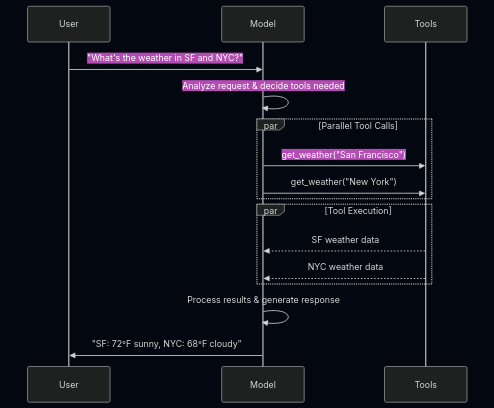

In [ ]:
from langchain.tools import tool

@tool
def get_weather(location: str) -> str:
    """Get the weather at a location."""
    return f"It's sunny in {location}."


model_with_tools = model.bind_tools([get_weather])

response = model_with_tools.invoke("What's the weather like in Boston?")
for tool_call in response.tool_calls:
    # View tool calls made by the model
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

Tool: get_weather
Args: {'location': 'Boston'}


#### Tool execution loop

When a model returns tool calls, you need to execute the tools and pass the results back to the model. This creates a conversation loop where the model can use tool results to generate its final response. LangChain includes agent abstractions that handle this orchestration for you

In [ ]:
model_with_tools = model.bind_tools([get_weather])

messages = [{"role": "user", "content": "What's the weather in Ahmedabad? (with degree celcius)"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

for tool_call in ai_msg.tool_calls:
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

final_repsonse = model_with_tools.invoke(messages)
print(final_repsonse.text)

The current weather in Ahmedabad is sunny. It didn’t provide a temperature in Celsius yet. If you’d like, I can fetch an updated temperature in °C for Ahmedabad.


Each ToolMessage returned by the tool includes a tool_call_id that matches the original tool call, helping the model correlate results with requests.

#### Forcing tool calls

In [ ]:
model_with_tools = model.bind_tools([tool_1], tool_choice="any")

#### Parallel tool calls

In [ ]:
model_with_tools = model.bind_tools([get_weather])

response = model_with_tools.invoke(
    "What's the weather in Boston and Tokyo?"
)


# The model may generate multiple tool calls
print(response.tool_calls)
# [
#   {'name': 'get_weather', 'args': {'location': 'Boston'}, 'id': 'call_1'},
#   {'name': 'get_weather', 'args': {'location': 'Tokyo'}, 'id': 'call_2'},
# ]


# Execute all tools (can be done in parallel with async)
results = []
for tool_call in response.tool_calls:
    if tool_call['name'] == 'get_weather':
        result = get_weather.invoke(tool_call)
    ...
    results.append(result)

[{'name': 'get_weather', 'args': {'location': 'Boston'}, 'id': 'call_fZokBXAr0QHTCbeD6tNWly9e', 'type': 'tool_call'}, {'name': 'get_weather', 'args': {'location': 'Tokyo'}, 'id': 'call_FWgbrS9M7V5vXc6MS6BqlypO', 'type': 'tool_call'}]


In [ ]:
model.bind_tools([get_weather], parallel_tool_calls=False)

_ChatModelBinding(bound=ChatOpenAI(output_version=None, profile={'name': 'GPT-5 Nano', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x76b838943e60>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x76b83445fa70>, root_client=<openai.OpenAI object at 0x76b83445fd40>, root_async_client=<openai.AsyncOpenAI object at 0x76b8387e7230>, model_name='gpt-5-nano', model_kwar

In [ ]:
model_with_tools = model.bind_tools([get_weather])

response = model_with_tools.invoke(
    "What's the weather in Boston and Tokyo?"
)


# The model may generate multiple tool calls
print(response.tool_calls)
# [
#   {'name': 'get_weather', 'args': {'location': 'Boston'}, 'id': 'call_1'},
#   {'name': 'get_weather', 'args': {'location': 'Tokyo'}, 'id': 'call_2'},
# ]


# Execute all tools (can be done in parallel with async)
results = []
for tool_call in response.tool_calls:
    if tool_call['name'] == 'get_weather':
        result = get_weather.invoke(tool_call)
    ...
    results.append(result)

[{'name': 'get_weather', 'args': {'location': 'Boston'}, 'id': 'call_UJuf7scXOk9beCR3StNcT5xq', 'type': 'tool_call'}]


#### Streaming tool calls

Models can be requested to provide their response in a format matching a given schema. This is useful for ensuring the output can be easily parsed and used in subsequent processing. LangChain supports multiple schema types and methods for enforcing structured output.

#### Pydantic

In [ ]:
from pydantic import BaseModel, Field

class movie(BaseModel):
    """ A movie with details"""
    title: str = Field(description="The title of the movie")
    year: int = Field(description="The year the mvoie was released")
    director: str = Field(description="The director of the movie")
    rating: float = Field(description="The movie's rating out of 10")

model_with_structure =  model.with_structured_output(movie, include_raw=True)
res = model_with_structure.invoke("Provide details about the movie Inception")

print(res)

{'raw': AIMessage(content='{"director":"Christopher Nolan","rating":8.8,"title":"Inception","year":2010}', additional_kwargs={'parsed': movie(title='Inception', year=2010, director='Christopher Nolan', rating=8.8), 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 123, 'total_tokens': 158, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Dh8KUrEyPVCM9AepZa22XdZEouYRK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3ef1-ca99-7142-81ad-22ea478f8db4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 123, 'output_tokens': 35, 'total_tokens': 158, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_

#### Json

In [ ]:
import json

json_schema = {
    "title": "Movie",
    "description": "A movie with details",
    "type": "object",
    "properties": {
        "title": {
            "type": "string",
            "description": "The title of the movie"
        },
        "year": {
            "type": "integer",
            "description": "The year the movie was released"
        },
        "director": {
            "type": "string",
            "description": "The director of the movie"
        },
        "rating": {
            "type": "number",
            "description": "The movie's rating out of 10"
        }
    },
    "required": ["title", "year", "director", "rating"]
}

model_with_structure = model.with_structured_output(
    json_schema,
    method="json_schema",
)
response = model_with_structure.invoke("Provide details about the movie Inception")
print(response)  # {'title': 'Inception', 'year': 2010, ...}

{'title': 'Inception', 'year': 2010, 'director': 'Christopher Nolan', 'rating': 8.8}


In [ ]:
from pydantic import BaseModel, Field

class Actor(BaseModel):
    name: str
    role: str

class MovieDetails(BaseModel):
    title: str
    year: int
    cast: list[Actor]
    genres: list[str]
    budget: float | None = Field(None, description="Budget in millions USD")

model_with_structure = model.with_structured_output(MovieDetails)

In [ ]:
response = model_with_structure.invoke("Provide details about the movie Inception")
print(response)

title='Inception' year=2010 cast=[Actor(name='Leonardo DiCaprio', role='Dom Cobb'), Actor(name='Joseph Gordon-Levitt', role='Arthur'), Actor(name='Elliot Page', role='Ariadne'), Actor(name='Tom Hardy', role='Eames'), Actor(name='Ken Watanabe', role='Saito'), Actor(name='Dilip Rao', role='Robert Fischer (adult)')] genres=['Action', 'Adventure', 'Sci-Fi'] budget=160.0


### Model profiles

```
model.profile
# {
#   "max_input_tokens": 400000,
#   "image_inputs": True,
#   "reasoning_output": True,
#   "tool_calling": True,
#   ...
# }

Much of the model profile data is powered by the models.dev project, an open source initiative that provides model capability data. These data are augmented with additional fields for purposes of use with LangChain. These augmentations are kept aligned with the upstream project as it evolves. Model profile data allow applications to work around model capabilities dynamically. For example:

    Summarization middleware can trigger summarization based on a model’s context window size.
    Structured output strategies in create_agent can be inferred automatically (e.g., by checking support for native structured output features).
    Model inputs can be gated based on supported modalities and maximum input tokens.
    Deep Agents Code filters the interactive model switcher to models whose profiles report tool_calling support and text I/O, and displays context window sizes and capability flags in the selector detail view.


### Multimodal

In [ ]:
response = model.invoke("Create a picture of a cat")
print(response.content_blocks)
# [
#     {"type": "text", "text": "Here's a picture of a cat"},
#     {"type": "image", "base64": "...", "mime_type": "image/jpeg"},
# ]

[{'type': 'text', 'text': "Here are a few simple cat pictures you can choose from. Let me know if you want a different style or size.\n\nOption 1: Cute cartoon cat\n /\\_/\\  \n( o.o ) \n > ^ <\n\nOption 2: More detailed ASCII cat\n /\\_/\\  \n(='.'=)\n(,SE,)\n\nOption 3: Sleepy cat\n /\\_/\\ \n( -.- ) zzz…\n\nOption 4: Pixel-style cat\n  /\\_/\\  \n ( •.• ) \n  > ^ <\n\nIf you’d like a digital image or a specific pose/color, tell me and I can generate something closer to what you want."}]


### Reasoning

In [ ]:
for chunk in model.stream("Why do parrots have colorful feathers?"):
    reasoning_steps = [r for r in chunk.content_blocks if r["type"] == "reasoning"]
    print(reasoning_steps if reasoning_steps else chunk.text)



Par
rots
 have
 colorful
 feathers
 mainly
 for
 three
 reasons
:


-
 Cam
ouflage
 and
 habitat
 communication
:
 In
 tropical
 forests
,
 d
apple
d
 light
 and
 bright
 flowers
 mean
 vivid
 colors
 help
 parro
ts
 blend
 with
 flowers
,
 fruit
,
 and
 foliage
 when
 seen
 by
 others
 of
 their
 species
.
 Bright
 patches
 can
 also
 help
 individuals
 recognize
 each
 other
 in
 dense
 forests
.


-
 Mate
 attraction
 and
 signaling
:
 Bright
,
 varied
 colors
 are
 often
 used
 to
 attract
 mates
.
 More
 vibrant
 plum
age
 can
 indicate
 good
 health
,
 good
 genes
,
 and
 a
 strong
 computer
 of
 fitness
,
 so
 individuals
 with
 brighter
 colors
 may
 have
 higher
 breeding
 success
.


-
 Social
 and
 species
 recognition
:
 Dist
inct
 color
 patterns
 help
 parro
ts
 identify
 members
 of
 their
 own
 species
 and
 even
 their
 social
 group
 or
 flock
,
 which
 is
 important
 for
 flock
 coordination
 and
 mating
.


How
 coloration
 develops
:

-
 Pig
ments
:
 Car
ot
eno
i

In [ ]:
from langchain.chat_models import init_chat_model

from langchain_openai import ChatOpenAI
model = ChatOpenAI(
    model="gpt-5-mini",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
)
tool = {"type": "web_search"}
model_with_tools = model.bind_tools([tool])

response = model_with_tools.invoke("What was cricket news from today?")
print(response.content_blocks)

PermissionDeniedError: Error code: 403 - {'error': {'message': '免费API限制使用deepseek-r1, deepseek-v3, gpt-3.5-turbo, gpt-4o-mini, gpt-4o, gpt-4.1-mini, gpt-4.1-nano, gpt-4.1, gpt-5-mini, gpt-5-nano, gpt-5和embeddings模型，如有更多需求，请访问 https://api.chatanywhere.tech/#/shop 购买付费API。The free account is limited to use deepseek-r1, deepseek-v3, gpt-3.5-turbo, gpt-4o-mini, gpt-4o and embeddings. If you have additional requirements, please visit https://api.chatanywhere.tech/#/shop to purchase a premium key.(当前请求使用的ApiKey: sk-3NN****Tl5Z)【如果您遇到问题，欢迎加入QQ群咨询：625105715】', 'type': 'chatanywhere_error', 'param': None, 'code': '403 FORBIDDEN'}}

In [ ]:
from langchain_core.rate_limiters import InMemoryRateLimiter

rate_limiter = InMemoryRateLimiter(
    requests_per_second=0.1,  # 1 request every 10s
    check_every_n_seconds=0.1,  # Check every 100ms whether allowed to make a request
    max_bucket_size=10,  # Controls the maximum burst size.
)
model = ChatOpenAI(
    model="gpt-5-mini",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
    rate_limiter=rate_limiter
)
model.invoke("what is latest date u are updated ?")

AIMessage(content='My training knowledge goes up to June 2024. I can access no real-time web data, so anything after that I may not know unless you provide details.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 14, 'total_tokens': 57, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini', 'system_fingerprint': None, 'id': 'chatcmpl-DhBRWefmn09IyUVw5ZQBBKPbEdUD0', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3fa8-3c16-7133-82aa-348b5ee36d57-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 43, 'total_tokens': 57, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [ ]:
model = init_chat_model(
    model="gpt-5-mini",
    model_provider="openai",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
)
response = model.invoke("what is langchain")
print(response.content)

LangChain is an open-source framework designed to help developers build applications that use large language models (LLMs) in useful, production-ready ways. Instead of treating an LLM as a single “call this model and return the text” box, LangChain provides building blocks and abstractions to integrate models into broader workflows and systems.

Key ideas and components:
- Prompt management: Tools to create, store, and format prompts (templates, prompt chaining, prompt serialization).
- Model interfaces: Standardized connectors for different LLM providers (OpenAI, Anthropic, Hugging Face, local models, etc.), plus utilities for streaming, batching, and response parsing.
- Chains: Composable sequences of steps (prompt → LLM → post-process → tool call → memory, etc.) so you can build multi-step flows.
- Tools and agents: Mechanisms to let an LLM call external tools (APIs, search, calculators) and to orchestrate decision-making (agents that choose tools/actions based on model outputs).
- 

In [ ]:
model = init_chat_model(
    model="gpt-5-mini",
    model_provider="openai",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
).bind(logprobs=True)

response = model.invoke("Why do parrots talk?")
print(response.response_metadata["logprobs"])

None


#### Callback handler


In [ ]:
from langchain.chat_models import init_chat_model
from langchain_core.callbacks import UsageMetadataCallbackHandler

model_1 = init_chat_model(model="gpt-5.4-mini",    
                          model_provider="openai",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"))
model_2 = init_chat_model(model="openai/gpt-oss-20b", 
                          model_provider="openrouter")

callback = UsageMetadataCallbackHandler()
result_1 = model_1.invoke("Hello", config={"callbacks": [callback]})
result_2 = model_2.invoke("Hello", config={"callbacks": [callback]})
print(callback.usage_metadata)

{'gpt-5.4-mini-2026-03-17': {'input_tokens': 7, 'output_tokens': 13, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}, 'openai/gpt-oss-20b': {'input_tokens': 68, 'output_tokens': 38, 'total_tokens': 106, 'input_token_details': {'cache_read': 0, 'cache_creation': 0}, 'output_token_details': {'reasoning': 20}}}


#### context manager

In [ ]:
from langchain.chat_models import init_chat_model
from langchain_core.callbacks import get_usage_metadata_callback

model_1 = init_chat_model(model="gpt-5.4-mini",    
                          model_provider="openai",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"))
model_2 = init_chat_model(model="openai/gpt-oss-20b", 
                          model_provider="openrouter")
with get_usage_metadata_callback() as cb:
    model_1.invoke("Hello")
    model_2.invoke("Hello")
    print(cb.usage_metadata)

{'gpt-5.4-mini-2026-03-17': {'input_tokens': 7, 'output_tokens': 13, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}, 'openai/gpt-oss-20b': {'input_tokens': 55, 'output_tokens': 57, 'total_tokens': 112, 'input_token_details': {'cache_read': 0, 'cache_creation': 0}, 'output_token_details': {'reasoning': 39}}}


In [ ]:
response = model.invoke(
    "Tell me a joke",
    config={
        "run_name": "joke_generation",      # Custom name for this run
        "tags": ["humor", "demo"],          # Tags for categorization
        "metadata": {"user_id": "123"},     # Custom metadata
        "callbacks": [callback], # Callback handlers
    }
)

In [ ]:
print(response)

content='Why did the scarecrow win an award?\n\nBecause he was outstanding in his field.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 10, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini', 'system_fingerprint': None, 'id': 'chatcmpl-DhBhXH25wYjR3WerlocDz8Gf4bFbE', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e3fb7-8b4e-7253-987a-11ca3dcf52e4-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 10, 'output_tokens': 27, 'total_tokens': 37, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


## Messages

Messages are the fundamental unit of context for models in LangChain. They represent the input and output of models, carrying both the content and metadata needed to represent the state of a conversation when interacting with an LLM. 

Messages are objects that contain:

    - Role - Identifies the message type (e.g. system, user)
    - Content - Represents the actual content of the message (like text, images, audio, documents, etc.)
    - Metadata - Optional fields such as response information, message IDs, and token usage


In [ ]:
model = init_chat_model(model="gpt-5.4-mini",    
                          model_provider="openai",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"))

### Basic usage

In [ ]:
from langchain.messages import HumanMessage, AIMessage, SystemMessage

system_msg = SystemMessage("You are an helpful assistant")
humna_msg = HumanMessage("Hello , how are u ?")

messages = [ system_msg, humna_msg]
res=model.invoke(messages)

In [ ]:
print(res)

content="Hi — I'm doing well, thanks! How are you? How can I help today?" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 21, 'total_tokens': 49, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini', 'system_fingerprint': None, 'id': 'chatcmpl-DhC6rhbJIf8brHySHVEoju6fiQTtc', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e3fcf-7d32-78e3-a4f4-571c36b42ed1-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 21, 'output_tokens': 28, 'total_tokens': 49, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


#### Text prompts

Text prompts are strings - ideal for straightforward generation tasks where you don’t need to retain conversation history.

#### Message prompts

In [ ]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage

messages = [
    SystemMessage("You are a poetry expert"),
    HumanMessage("Write a haiku about spring"),
    AIMessage("Cherry blossoms bloom...")
]
response = model.invoke(messages)

In [ ]:
print(response)

content='Soft rain wakes the buds —\ngreen whispers along the lane,\nsparrows stitch the light.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 31, 'total_tokens': 59, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DhCKQgjpX4hTKnTcZfJsGSwvaYFBl', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e3fdc-4f0f-77d0-b03f-526909185810-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 31, 'output_tokens': 28, 'total_tokens': 59, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


#### Dictionary format

In [ ]:
messages = [
    {"role": "system", "content": "You are a poetry expert"},
    {"role": "user", "content": "Write a haiku about spring"},
    {"role": "assistant", "content": "Cherry blossoms bloom..."}
]
response = model.invoke(messages)

#### System message

In [ ]:
system_msg = SystemMessage("You are a helpful coding assistant.")

messages = [
    system_msg,
    HumanMessage("How do I create a REST API?")
]
response = model.invoke(messages)

In [ ]:
print(response)

content='Creating a REST API involves designing HTTP endpoints that expose resources, implementing those endpoints on a server, and handling requests and responses in a standard way. Below is a practical, technology-agnostic guide plus short examples in two popular stacks (Node.js/Express and Python/Flask) so you can start quickly.\n\nOverview — key concepts\n- Resources: the entities your API exposes (users, posts, orders).\n- URIs: each resource or collection has a URL (e.g., /users, /users/{id}).\n- HTTP methods:\n  - GET to read,\n  - POST to create,\n  - PUT or PATCH to update,\n  - DELETE to remove.\n- Status codes: indicate result (200/201/204/400/401/404/500).\n- Representations: usually JSON.\n- Stateless: server does not keep client state between requests.\n- Versioning: include version in the path or headers (e.g., /v1/users).\n- Authentication & authorization: e.g., API keys, OAuth, JWT.\n- Documentation: OpenAPI/Swagger helps clients use your API.\n- Validation & error han

In [ ]:
from langchain.messages import SystemMessage, HumanMessage

system_msg = SystemMessage("""
You are a senior Python developer with expertise in web frameworks.
Always provide code examples and explain your reasoning.
Be concise but thorough in your explanations.
""")

messages = [
    system_msg,
    HumanMessage("How do I create a REST API?")
]
response = model.invoke(messages)
print(response)

content='Creating a REST API means designing HTTP endpoints that let clients create, read, update, and delete resources over the web in a predictable way. I\'ll give you a concise, practical guide with examples in two popular Python frameworks (Flask and FastAPI), explain key design decisions, and show testing and deployment basics.\n\nHigh-level steps\n1. Define resources and operations. Decide what resources (users, posts, products) and which HTTP methods map to operations (GET, POST, PUT/PATCH, DELETE).\n2. Design URL structure and payloads. Use plural nouns (/users, /posts/{id}), consistent naming, and JSON payloads.\n3. Choose a framework and tools. Examples below use Flask (microframework) and FastAPI (modern, async, built-in OpenAPI).\n4. Implement handlers, validation, authentication, and errors.\n5. Add tests, docs, and deploy.\n\nKey design guidelines\n- Use nouns (not verbs) for endpoints: GET /books, POST /books.\n- Use standard HTTP status codes: 200 OK, 201 Created (on PO

### Human message

A HumanMessage represents user input and interactions. They can contain text, images, audio, files, and any other amount of multimodal content.

#### Text content

In [ ]:
response = model.invoke([
  HumanMessage("What is machine learning?")
])

#### Message metadata

In [ ]:
human_msg = HumanMessage(
    content="Hello!",
    name="alice",  # Optional: identify different users
    id="msg_123",  # Optional: unique identifier for tracing
)

### AI MEssage

An AIMessage represents the output of a model invocation. They can include multimodal data, tool calls, and provider-specific metadata that you can later access.

In [ ]:
response = model.invoke("Explain AI")
print(type(response))  # <class 'langchain.messages.AIMessage'>

<class 'langchain_core.messages.ai.AIMessage'>


AIMessage objects are returned by the model when calling it, which contains all of the associated metadata in the response.

In [ ]:
from langchain.messages import AIMessage, SystemMessage, HumanMessage

# Create an AI message manually (e.g., for conversation history)
ai_msg = AIMessage("I'd be happy to help you with that question!")

# Add to conversation history
messages = [
    SystemMessage("You are a helpful assistant"),
    HumanMessage("Can you help me?"),
    ai_msg,  # Insert as if it came from the model
    HumanMessage("Great! What's 2+2?")
]

response = model.invoke(messages)
print(response)

content='2 + 2 = 4' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 48, 'total_tokens': 65, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DhCnHHjPzaSgHGYueQ9sJWRCLjpHD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e3ff7-90ac-7483-bb25-9668bff39edb-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 48, 'output_tokens': 17, 'total_tokens': 65, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


#### Tool calls

In [ ]:
from langchain.chat_models import init_chat_model


def get_weather(location: str) -> str:
    """Get the weather at a location."""
    ...

model_with_tools = model.bind_tools([get_weather])
response = model_with_tools.invoke("What's the weather in Paris?")

for tool_call in response.tool_calls:
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")
    print(f"ID: {tool_call['id']}")

Tool: get_weather
Args: {'location': 'Paris, France'}
ID: call_Zr6xIRVhcrbVdeQyOORZahgG


In [ ]:
response.usage_metadata

{'input_tokens': 131,
 'output_tokens': 26,
 'total_tokens': 157,
 'input_token_details': {'audio': 0, 'cache_read': 0},
 'output_token_details': {'audio': 0, 'reasoning': 0}}

#### Streaming and chunks

In [ ]:
chunks = []
full_message = None
for chunk in model.stream("Hi"):
    chunks.append(chunk)
    print(chunk.text)
    full_message = chunk if full_message is None else full_message + chunk



Hello
!
 How
 can
 I
 help
 you
 today
?





#### Tool message

In [ ]:
from langchain.messages import AIMessage
from langchain.messages import ToolMessage

# After a model makes a tool call
# (Here, we demonstrate manually creating the messages for brevity)
ai_message = AIMessage(
    content=[],
    tool_calls=[{
        "name": "get_weather",
        "args": {"location": "San Francisco"},
        "id": "call_123"
    }]
)

# Execute tool and create result message
weather_result = "Sunny, 72°F"
tool_message = ToolMessage(
    content=weather_result,
    tool_call_id="call_123"  # Must match the call ID
)

# Continue conversation
messages = [
    HumanMessage("What's the weather in San Francisco?"),
    ai_message,  # Model's tool call
    tool_message,  # Tool execution result
]
response = model.invoke(messages)  # Model processes the result

In [ ]:
print(response)

content="It's sunny in San Francisco and about 72°F right now. Would you like the forecast for today or the next few days, or any details like wind, humidity, or sunrise/sunset times?" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 47, 'total_tokens': 97, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini', 'system_fingerprint': None, 'id': 'chatcmpl-DhCvEaxdpCFOP5OIWch250XjuBAvF', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e3fff-2858-7750-9148-6c10416cc7e0-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 47, 'output_tokens': 50, 'total_tokens': 97, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoni

##### artifact

The artifact field stores supplementary data that won’t be sent to the model but can be accessed programmatically. This is useful for storing raw results, debugging information, or data for downstream processing without cluttering the model’s context.

In [ ]:
from langchain.messages import ToolMessage

# Sent to model
message_content = "It was the best of times, it was the worst of times."

# Artifact available downstream
artifact = {"document_id": "doc_123", "page": 0}

tool_message = ToolMessage(
    content=message_content,
    tool_call_id="call_123",
    name="search_books",
    artifact=artifact,
)

### Message content


In [ ]:
from langchain.messages import HumanMessage

# String content
human_message = HumanMessage("Hello, how are you?")

# Provider-native format (e.g., OpenAI)
human_message = HumanMessage(content=[
    {"type": "text", "text": "Hello, how are you?"},
    {"type": "image_url", "image_url": {"url": "https://example.com/image.jpg"}}
])

# List of standard content blocks
human_message = HumanMessage(content_blocks=[
    {"type": "text", "text": "Hello, how are you?"},
    {"type": "image", "url": "https://example.com/image.jpg"},
])

In [ ]:
from langchain.messages import AIMessage

message = AIMessage(
    content=[
        {
            "type": "reasoning",
            "id": "rs_abc123",
            "summary": [
                {"type": "summary_text", "text": "summary 1"},
                {"type": "summary_text", "text": "summary 2"},
            ],
        },
        {"type": "text", "text": "...", "id": "msg_abc123"},
    ],
    response_metadata={"model_provider": "openai"}
)
message.content_blocks

[{'type': 'reasoning', 'id': 'rs_abc123', 'reasoning': 'summary 1'},
 {'type': 'reasoning', 'id': 'rs_abc123', 'reasoning': 'summary 2'},
 {'type': 'text', 'text': '...', 'id': 'msg_abc123'}]

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-5-nano", 
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
    output_version="v1")

model.invoke("hi")

AIMessage(content=[{'type': 'text', 'text': 'Hello! How can I help you today?'}], additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 7, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DhE6Av8DZNRYe7l1wmbBczLERe4Py', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None, 'output_version': 'v1'}, id='lc_run--019e4044-282b-73e0-8a3a-99159963f036-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 19, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

## Tools

Tools extend what agents can do—letting them fetch real-time data, execute code, query external databases, and take actions in the world.

### Create tools

#### Basic tool definition

In [ ]:
from langchain.tools import tool

@tool
def search_database(query: str, limit: int = 10) -> str:
    """Search the customer database for records matching the query.

    Args:
        query: Search terms to look for
        limit: Maximum number of results to return
    """
    return f"Found {limit} results for '{query}'"

### Customize tool properties
#### Custom tool name

In [ ]:
@tool("web_search")  # Custom name
def search(query: str) -> str:
    """Search the web for information."""
    return f"Results for: {query}"

print(search.name)  # web_search

web_search


#### Custom tool description

In [ ]:
@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

#### Advanced schema definition


In [ ]:
from pydantic import BaseModel, Field
from typing import Literal

class WeatherInput(BaseModel):
    """Input for weather queries."""
    location: str = Field(description="City name or coordinates")
    units: Literal["celsius", "fahrenheit"] = Field(
        default="celsius",
        description="Temperature unit preference"
    )
    include_forecast: bool = Field(
        default=False,
        description="Include 5-day forecast"
    )

@tool(args_schema=WeatherInput)
def get_weather(location: str, units: str = "celsius", include_forecast: bool = False) -> str:
    """Get current weather and optional forecast."""
    temp = 22 if units == "celsius" else 72
    result = f"Current weather in {location}: {temp} degrees {units[0].upper()}"
    if include_forecast:
        result += "\nNext 5 days: Sunny"
    return result

### Access Context

Tools are most powerful when they can access runtime information like conversation history, user data, and persistent memory. This section covers how to access and update this information from within your tools. Tools can access runtime information through the ToolRuntime parameter, which provides:

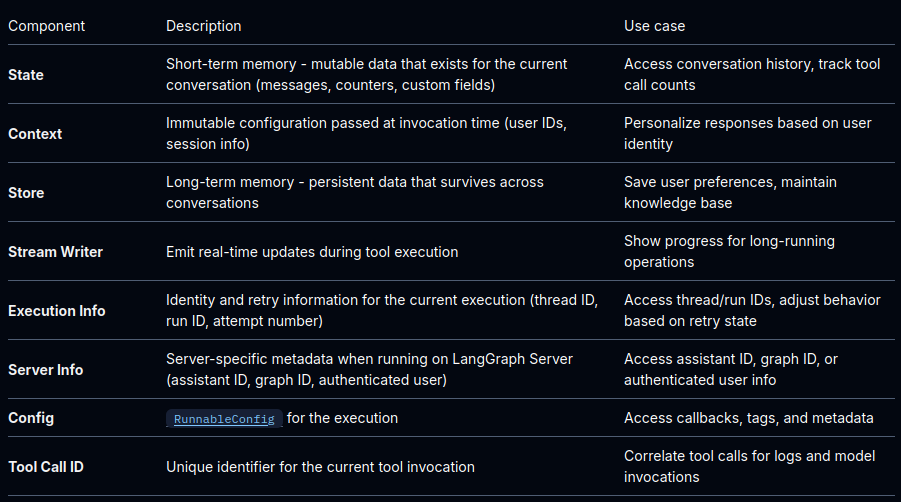

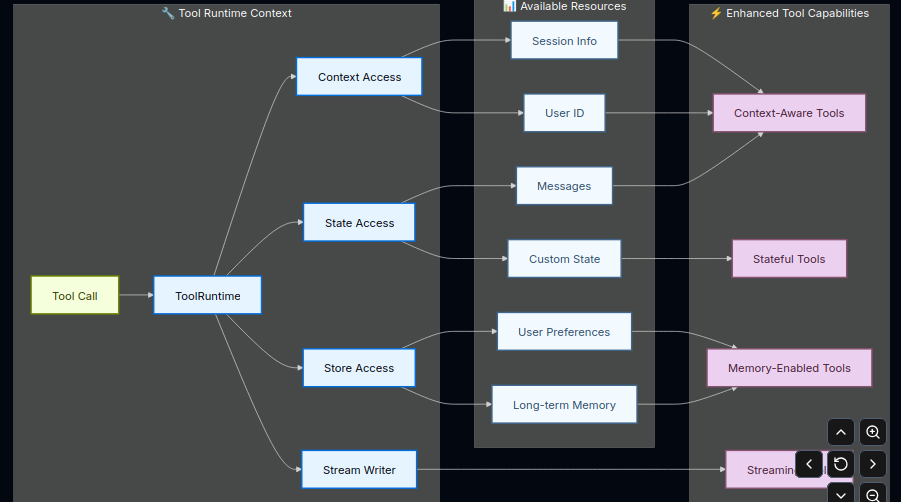

### Short-term memory (State)

State represents short-term memory that exists for the duration of a conversation. It includes the message history and any custom fields you define in your graph state.

#### Access state

Tools can access the current conversation state using runtime.state:

In [ ]:
from langchain.tools import tool, ToolRuntime
from langchain.messages import HumanMessage

@tool
def get_last_user_message(runtime: ToolRuntime) -> str:
    """Get the most recent message from the user."""
    messages = runtime.state["messages"]

    # Find the last human message
    for message in reversed(messages):
        if isinstance(message, HumanMessage):
            return message.content

    return "No user messages found"

# Access custom state fields
@tool
def get_user_preference(
    pref_name: str,
    runtime: ToolRuntime
) -> str:
    """Get a user preference value."""
    preferences = runtime.state.get("user_preferences", {})
    return preferences.get(pref_name, "Not set")

#### Update state

In [ ]:
from langchain.agents import AgentState
from langchain.messages import ToolMessage
from langchain.tools import ToolRuntime, tool
from langgraph.types import Command


class CustomState(AgentState):
    user_name: str


@tool
def set_user_name(new_name: str, runtime: ToolRuntime[None, CustomState]) -> Command:
    """Set the user's name in the conversation state."""
    return Command(
        update={
            "user_name": new_name,
            "messages": [
                ToolMessage(
                    content=f"User name set to {new_name}.",
                    tool_call_id=runtime.tool_call_id,
                )
            ],
        }
    )

#### Context

Context provides immutable configuration data that is passed at invocation time. Use it for user IDs, session details, or application-specific settings that shouldn’t change during a conversation.

In [ ]:
from dataclasses import dataclass
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime


USER_DATABASE = {
    "user123": {
        "name": "Alice Johnson",
        "account_type": "Premium",
        "balance": 5000,
        "email": "alice@example.com"
    },
    "user456": {
        "name": "Bob Smith",
        "account_type": "Standard",
        "balance": 1200,
        "email": "bob@example.com"
    }
}

@dataclass
class UserContext:
    user_id: str

@tool
def get_account_info(runtime: ToolRuntime[UserContext]) -> str:
    """Get the current user's account information."""
    user_id = runtime.context.user_id

    if user_id in USER_DATABASE:
        user = USER_DATABASE[user_id]
        return f"Account holder: {user['name']}\nType: {user['account_type']}\nBalance: ${user['balance']}"
    return "User not found"

model = ChatOpenAI(model="gpt-5-mini", 
                   api_key=os.getenv("API_KEY"),
                  base_url=os.getenv("BASE_URL"))
agent = create_agent(
    model,
    tools=[get_account_info],
    context_schema=UserContext,
    system_prompt="You are a financial assistant."
)

result = agent.invoke(
    {"messages": [{"role": "user", "content": "What's my current balance?"}]},
    context=UserContext(user_id="user123")
)

In [ ]:
print(result)

{'messages': [HumanMessage(content="What's my current balance?", additional_kwargs={}, response_metadata={}, id='f567e93c-b0ee-44a2-b2cb-d7cd99da271b'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 134, 'total_tokens': 155, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DhSXgNNjb6FDWTmD1OpHqz92NZgp4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e4393-59b6-70f2-abc1-e2bbadb8e2fa-0', tool_calls=[{'name': 'get_account_info', 'args': {}, 'id': 'call_HRrVNXw70e9rMehYi9orCPS4', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 134, 'output_tokens': 21, 'tot

### Long-term memory(Store) 

The BaseStore provides persistent storage that survives across conversations. Unlike state (short-term memory), data saved to the store remains available in future sessions.

In [ ]:
from typing import Any
from langgraph.store.memory import InMemoryStore
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime
from langchain_openai import ChatOpenAI

# Access memory
@tool
def get_user_info(user_id: str, runtime: ToolRuntime) -> str:
    """ Look up user info"""
    store=runtime.store
    user_info = store.get(("users",), user_id)
    return str(user_info.value) if user_info else "Unknown user"

# Update memory
@tool
def save_user_info(user_id: str, user_info: dict[str,Any], runtime: ToolRuntime) -> str:
    """ Save user info."""
    store = runtime.store
    store.put(("users",), user_id, user_info)
    return "Successfully saved user info."

model = ChatOpenAI(model="gpt-3.5-turbo", 
                   api_key=os.getenv("API_KEY"),
                  base_url=os.getenv("BASE_URL"))
store = InMemoryStore()
agent=create_agent(
    model,
    tools = [get_user_info, save_user_info],
    store=store
)

agent.invoke({
    "messages": [{"role": "user", "content": "Save the following user: userid: abc123, name: Foo, age: 25, email: foo@langchain.dev"}]
    
})


{'messages': [HumanMessage(content='Save the following user: userid: abc123, name: Foo, age: 25, email: foo@langchain.dev', additional_kwargs={}, response_metadata={}, id='a719e46d-6588-48c2-b980-032327855ee2'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 90, 'total_tokens': 108, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DhTCBFmXwyiuCx8ZWVPomWiemxHey', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e43b9-aac4-72e0-8b68-1ed662b5ac09-0', tool_calls=[{'name': 'save_user_info', 'args': {'user_id': 'abc123'}, 'id': 'call_lcGEuCHVxIp49rDJuW8bhhRr', 'type': 'tool_call'

In [ ]:
agent.invoke({
    "messages": [{"role": "user", "content": "Get user info for user with id 'abc123'"}]
})

{'messages': [HumanMessage(content="Get user info for user with id 'abc123'", additional_kwargs={}, response_metadata={}, id='9f6b4e3c-7935-4bd2-b237-5d765491e58a'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 75, 'total_tokens': 93, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DhTCnQzkCOU1USJhqRO4Ovovfdezs', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e43ba-3fc6-7102-aaf2-3eb4b2f51ca5-0', tool_calls=[{'name': 'get_user_info', 'args': {'user_id': 'abc123'}, 'id': 'call_HIoBWhedI5aDG1BYToRJI3du', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'inpu

#### Stream writer

Access thread ID, run ID, and retry state from within a tool via runtime.execution_info:

In [ ]:
from langchain.tools import tool, ToolRuntime

@tool
def log_execution_context(runtime: ToolRuntime) ->str:
    """ Log Execution identity information"""
    info =  runtime.execution_info
    print(f"Thread: {info.thread_info}, Run: {info.run_id}")
    print(f"Attempt: {info.node_attempt}")
    return "done"


#### Server info

When your tool runs on LangGraph Server, access the assistant ID, graph ID, and authenticated user via runtime.server_info:

In [ ]:
from langchain.tools import tool, ToolRuntime

@tool
def get_assistant_scoped_data(runtime: ToolRuntime) -> str:
    """Fetch data scoped to the current assistant."""
    server = runtime.server_info
    if server is not None:
        print(f"Assistant: {server.assistant_id}, Graph: {server.graph_id}")
        if server.user is not None:
            print(f"User: {server.user.identity}")
    return "done"

server_info is None when the tool is not running on LangGraph Server (e.g., during local development or testing).

### Tool execution

In LangChain, tools are used by agents (for example via create_agent) and tool error handling is configured through middleware.

#### Tool return values

- Return a string for human-readable results.
- Return an object for structured results the model should parse.
- Return a Command with optional message when you need to write to state.

string

In [ ]:
from langchain.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get weather for a city."""
    return f"It is currently sunny in {city}."

Behavior:

    The return value is converted to a ToolMessage.
    The model sees that text and decides what to do next.
    No agent state fields are changed unless the model or another tool does so later.


object

In [ ]:
from langchain.tools import tool

@tool
def get_weather_data(city: str) -> dict:
    """Get structured weather data for a city."""
    return {
        "city": city,
        "temperature_c": 22,
        "conditions": "sunny",
    }

Behavior:

    The object is serialized and sent back as tool output.
    The model can read specific fields and reason over them.
    Like string returns, this does not directly update graph state.


command

In [ ]:
from langchain.messages import ToolMessage
from langchain.tools import ToolRuntime, tool
from langgraph.types import Command


@tool
def set_language(language: str, runtime: ToolRuntime) -> Command:
    """Set the preferred response language."""
    return Command(
        update={
            "preferred_language": language,
            "messages": [
                ToolMessage(
                    content=f"Language set to {language}.",
                    tool_call_id=runtime.tool_call_id,
                )
            ],
        }
    )

Behavior:

    The command updates state using update.
    Updated state is available to subsequent steps in the same run.
    Use reducers for fields that may be updated by parallel tool calls.


Use this when the tool is not just returning data, but also mutating agent state.

### Error handling

Handle tool errors using LangChain agent middleware to retry failed tool calls or return custom error messages:

In [ ]:
from collections.abc import Callable

from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain.messages import ToolMessage
from langchain.tools.tool_node import ToolCallRequest


@wrap_tool_call
def handle_tool_errors(
    request: ToolCallRequest,
    handler: Callable[[ToolCallRequest], ToolMessage],
) -> ToolMessage:
    """Convert tool exceptions into ToolMessages the model can handle."""
    try:
        return handler(request)
    except Exception as e:
        return ToolMessage(
            content=f"Tool error: Please check your input and try again. ({e})",
            tool_call_id=request.tool_call["id"],
        )


agent = create_agent(
    model,
    tools=[],
    middleware=[handle_tool_errors],
)

In [ ]:
agent.invoke("hi")

InvalidUpdateError: Expected dict, got hi
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE

### State injection

In [ ]:
from langchain.tools import tool, ToolRuntime

@tool
def get_message_count(runtime: ToolRuntime) -> str:
    """Get the number of messages in the conversation."""
    messages = runtime.state["messages"]
    return f"There are {len(messages)} messages."

## Structured output

Structured output allows agents to return data in a specific, predictable format. Instead of parsing natural language responses, you get structured data in the form of JSON objects, Pydantic models, or dataclasses that your application can use directly.

### Response format

In [ ]:
def create_agent(
    ...
    response_format: Union[
        ToolStrategy[StructuredResponseT],
        ProviderStrategy[StructuredResponseT],
        type[StructuredResponseT],
        None,
)

In [ ]:
custom_profile = {
    "structured_output": True,
    # ...
}
model = init_chat_model("...", profile=custom_profile)

The structured response is returned in the structured_response key of the agent’s final state.

### Provider strategy

In [ ]:
class ProviderStrategy(Generic[SchemaT]):
    schema: type[SchemaT]
    strict: bool | None = None

NameError: name 'Generic' is not defined

In [ ]:
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
import os

class ContactInfo(BaseModel):
    """Contact information for a person."""
    name: str = Field(description="The name of the person")
    email: str = Field(description="The email address of the person")
    phone: str = Field(description="The phone number of the person")
model = ChatOpenAI(
    model = "gpt-5-mini",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL")
)
agent = create_agent(
    model,
    response_format=ContactInfo  # Auto-selects ProviderStrategy
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

print(result["structured_response"])
# ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')

name='John Doe' email='john@example.com' phone='(555) 123-4567'


### Tool calling strategy

For models that don’t support native structured output, LangChain uses tool calling to achieve the same result. This works with all models that support tool calling (most modern models).

In [ ]:
class ToolStrategy(Generic[SchemaT]):
    schema: type[SchemaT]
    tool_message_content: str | None
    handle_errors: Union[
        bool,
        str,
        type[Exception],
        tuple[type[Exception], ...],
        Callable[[Exception], str],
    ]

schema
required
The schema defining the structured output format. Supports:

    Pydantic models: BaseModel subclasses with field validation. Returns validated Pydantic instance.
    Dataclasses: Python dataclasses with type annotations. Returns dict.
    TypedDict: Typed dictionary classes. Returns dict.
    JSON Schema: Dictionary with JSON schema specification. Returns dict.
    Union types: Multiple schema options. The model will choose the most appropriate schema based on the context.


In [ ]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy


class ProductReview(BaseModel):
    """Analysis of a product review."""
    rating: int | None = Field(description="The rating of the product", ge=1, le=5)
    sentiment: Literal["positive", "negative"] = Field(description="The sentiment of the review")
    key_points: list[str] = Field(description="The key points of the review. Lowercase, 1-3 words each.")

agent = create_agent(
    model,
    tools=tools,
    response_format=ToolStrategy(ProductReview)
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Analyze this review: 'Great product: 5 out of 5 stars. Fast shipping, but expensive'"}]
})
result["structured_response"]
# ProductReview(rating=5, sentiment='positive', key_points=['fast shipping', 'expensive'])

NameError: name 'tools' is not defined

### Custom tool messsage content

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
import json


class MeetingAction(BaseModel):
    """Action items extracted from a meeting transcript."""
    task: str = Field(description="The specific task to be completed")
    assignee: str = Field(description="Person responsible for the task")
    priority: Literal["low", "medium", "high"] = Field(description="Priority level")

agent = create_agent(
    model,
    tools=[],
    response_format=ToolStrategy(
        schema=MeetingAction,
        tool_message_content="Action item captured and added to meeting notes!"
    )
)

res= agent.invoke({
    "messages": [{"role": "user", "content": "From our meeting: Sarah needs to update the project timeline as soon as possible"}]
})

for msg in res["messages"]:
    msg.pretty_print()


================================ Human Message =================================

From our meeting: Sarah needs to update the project timeline as soon as possible
================================== Ai Message ==================================
Tool Calls:
  MeetingAction (call_VsVNSdCODEHR2lp66f7eVgxX)
 Call ID: call_VsVNSdCODEHR2lp66f7eVgxX
  Args:
    assignee: Sarah
    priority: high
    task: Update the project timeline as soon as possible.
================================= Tool Message =================================
Name: MeetingAction

Action item captured and added to meeting notes!


### Error handling

In [ ]:
from pydantic import BaseModel, Field
from typing import Union
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy


class ContactInfo(BaseModel):
    name: str = Field(description="Person's name")
    email: str = Field(description="Email address")

class EventDetails(BaseModel):
    event_name: str = Field(description="Name of the event")
    date: str = Field(description="Event date")

agent = create_agent(
    model,
    tools=[],
    response_format=ToolStrategy(Union[ContactInfo, EventDetails])  # Default: handle_errors=True
)

res=agent.invoke({
    "messages": [{"role": "user", "content": "Extract info: John Doe (john@email.com) is organizing Tech Conference on March 15th"}]
})

In [ ]:
for msg in res["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Extract info: John Doe (john@email.com) is organizing Tech Conference on March 15th
================================== Ai Message ==================================
Tool Calls:
  EventDetails (call_63AV0dQukPG14CFXdGmD7ZXY)
 Call ID: call_63AV0dQukPG14CFXdGmD7ZXY
  Args:
    event_name: Tech Conference
    date: March 15
================================= Tool Message =================================
Name: EventDetails

Returning structured response: event_name='Tech Conference' date='March 15'


### Schema validation error

In [ ]:
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy


class ProductRating(BaseModel):
    rating: int | None = Field(description="Rating from 1-5", ge=1, le=5)
    comment: str = Field(description="Review comment")

agent = create_agent(
    model,
    tools=[],
    response_format=ToolStrategy(ProductRating),  # Default: handle_errors=True
    system_prompt="You are a helpful assistant that parses product reviews. Do not make any field or value up."
)

res=agent.invoke({
    "messages": [{"role": "user", "content": "Parse this: Amazing product, 10/10!"}]
})
for msg in res["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Parse this: Amazing product, 10/10!
================================== Ai Message ==================================
Tool Calls:
  ProductRating (call_blSyu2P5PMTi930ME0lxEsyx)
 Call ID: call_blSyu2P5PMTi930ME0lxEsyx
  Args:
    comment: Amazing product, 10/10!
    rating: 5
================================= Tool Message =================================
Name: ProductRating

Returning structured response: rating=5 comment='Amazing product, 10/10!'


### Error handling strategies

In [ ]:
ToolStrategy(
    schema=ProductRating,
    handle_errors="Please provide a valid rating between 1-5 and include a comment."
)

#### Custom error handler function:

In [ ]:
from langchain.agents.structured_output import StructuredOutputValidationError
from langchain.agents.structured_output import MultipleStructuredOutputsError

def custom_error_handler(error: Exception) -> str:
    if isinstance(error, StructuredOutputValidationError):
        return "There was an issue with the format. Try again."
    elif isinstance(error, MultipleStructuredOutputsError):
        return "Multiple structured outputs were returned. Pick the most relevant one."
    else:
        return f"Error: {str(error)}"


agent = create_agent(
    model,
    tools=[],
    response_format=ToolStrategy(
                        schema=Union[ContactInfo, EventDetails],
                        handle_errors=custom_error_handler
                    )  # Default: handle_errors=True
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract info: John Doe (john@email.com) is organizing Tech Conference on March 15th"}]
})

for msg in result['messages']:
    # If message is actually a ToolMessage object (not a dict), check its class name
    if type(msg).__name__ == "ToolMessage":
        print(msg.content)
    # If message is a dictionary or you want a fallback
    elif isinstance(msg, dict) and msg.get('tool_call_id'):
        print(msg['content'])

Returning structured response: event_name='Tech Conference' date='March 15th'


#### No error handling:

In [ ]:
response_format = ToolStrategy(
    schema=ProductRating,
    handle_errors=False  # All errors raised
)

## Guardrails


Guardrails help you build safe, compliant AI applications by validating and filtering content at key points in your agent’s execution. They can detect sensitive information, enforce content policies, validate outputs, and prevent unsafe behaviors before they cause problems.

Common use cases include:

    Preventing PII leakage
    Detecting and blocking prompt injection attacks
    Blocking inappropriate or harmful content
    Enforcing business rules and compliance requirements
    Validating output quality and accuracy


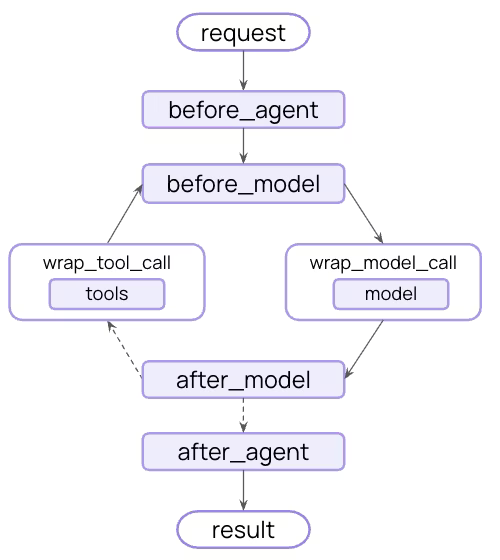

Guardrails can be implemented using two complementary approaches:

- Deterministic guardrails
Use rule-based logic like regex patterns, keyword matching, or explicit checks. Fast, predictable, and cost-effective, but may miss nuanced violations.

- Model-based guardrails
Use LLMs or classifiers to evaluate content with semantic understanding. Catch subtle issues that rules miss, but are slower and more expensive.

LangChain provides both built-in guardrails (e.g., PII detection, human-in-the-loop) and a flexible middleware system for building custom guardrails using either approach.

### Built-in guardrails

#### PII detection

LangChain provides built-in middleware for detecting and handling Personally Identifiable Information (PII) in conversations. This middleware can detect common PII types like emails, credit cards, IP addresses, and more. 

PII detection middleware is helpful for cases such as health care and financial applications with compliance requirements, customer service agents that need to sanitize logs, and generally any application handling sensitive user data. 

The PII middleware supports multiple strategies for handling detected PII:

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from pydantic import BaseModel, Field
from typing import Literal

import os
from dotenv import load_dotenv
load_dotenv()

model = ChatOpenAI(
    model="gpt-5-mini",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"))
# Define input schemas for better clarity
class CustomerServiceInput(BaseModel):
    customer_id: str = Field(description="Unique customer identifier")
    action: Literal["lookup", "update_status", "resolve_issue"] = Field(description="Type of service action")
    details: str = Field(description="Additional details about the request")

class EmailInput(BaseModel):
    recipient: str = Field(description="Email address of recipient")
    subject: str = Field(description="Email subject line")
    body: str = Field(description="Email body content")

# Customer Service Tool
@tool(args_schema=CustomerServiceInput)
def customer_service_tool(customer_id: str, action: str, details: str) -> str:
    """
    Handle customer service requests including lookups, status updates, and issue resolution.
    
    Args:
        customer_id: The unique customer ID
        action: Type of action (lookup, update_status, resolve_issue)
        details: Additional context or information
    """
    if action == "lookup":
        return f"Customer {customer_id} lookup: Account active, last contact 3 days ago. Details: {details}"
    elif action == "update_status":
        return f"Updated customer {customer_id} status. {details}"
    elif action == "resolve_issue":
        return f"Issue for customer {customer_id} marked as resolved. Resolution: {details}"
    else:
        return f"Unknown action: {action}"

# Email Tool
@tool(args_schema=EmailInput)
def email_tool(recipient: str, subject: str, body: str) -> str:
    """
    Send an email to a customer or support contact.
    
    Args:
        recipient: Email address to send to
        subject: Subject line of the email
        body: Main content of the email
    """
    # In production, integrate with actual email service (SendGrid, AWS SES, etc.)
    return f"Email sent to {recipient}\nSubject: {subject}\nStatus: Delivered"
agent = create_agent(
    model ,
    tools=[customer_service_tool, email_tool],
    middleware=[
        
        PIIMiddleware(
            "email",
            strategy="redact",
            apply_to_input=True,
        ),
        
        PIIMiddleware(
            "credit_card",
            strategy="mask",
            apply_to_input=True,
        ),
        PIIMiddleware(
            "api_key",
            detector=r"sk-[a-zA-Z0-9]{32}",
            strategy="block",
            apply_to_input=True
        )
    ]
)

result = agent.invoke({
    "messages": [{"role": "user", "content":"My email is john.doe@example.com and card is 5105-1051-0510-5100"}]
    
    
})

In [ ]:
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

My email is [REDACTED_EMAIL] and card is ****-****-****-5100
================================== Ai Message ==================================

Thanks — I can’t accept or store full card numbers or other sensitive payment data. For security, I’ve removed the card digits you included.

If you need help with a customer service task (lookup, status update, or resolving an issue), tell me:
- The customer ID or the last 4 digits of the card (already included: 5100) you want to use for lookup,
- What action you want (lookup, update_status, or resolve_issue),
- Any relevant details (order number, date, what outcome you want).

If you want me to send an email to the address you gave, confirm the recipient and provide the subject and body, and I’ll send it. (Note: don’t include full card numbers or other sensitive data in the email body.) Which would you like me to do?


### Human-in-the-loop

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command
from pydantic import BaseModel, Field
from langchain.tools import tool
from langchain_openrouter import ChatOpenRouter
model = ChatOpenRouter(
    model="openai/gpt-oss-20b")

class SearchToolInput(BaseModel):
    query: str = Field(description="Search query")
    limit: int = Field(default=10, description="Maximum number of results to return")

@tool(args_schema=SearchToolInput, description="Search the database for matching records.")
def search_tool(query: str, limit: int = 10) -> str:
    return f"Found up to {limit} results for '{query}'."

class SendEmailInput(BaseModel):
    recipient: str = Field(description="Email address of the recipient")
    subject: str = Field(description="Email subject line")
    body: str = Field(description="Email body content")

@tool(args_schema=SendEmailInput, description="Send an email to a recipient.")
def send_email_tool(recipient: str, subject: str, body: str) -> str:
    return f"Email sent to {recipient}\nSubject: {subject}\nBody: {body}"

class DeleteDatabaseInput(BaseModel):
    table: str = Field(description="Database table or collection name")
    record_id: str = Field(description="ID of the record to delete")

@tool(args_schema=DeleteDatabaseInput, description="Delete a record from the database.")
def delete_database_tool(table: str, record_id: str) -> str:
    return f"Deleted record {record_id} from table {table}."
agent= create_agent(
    model,
    tools = [search_tool, send_email_tool, delete_database_tool],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email":True,
                "delete+database":True,
                
                "search":False,
            }
        ),
    ],
    
    checkpointer = InMemorySaver()
)
config = {"configurable": {"thread_id": "some_id"}}

result = agent.invoke(
    {"messages": [{"role": "user", "content": "Send an email to the team"}]},
    config=config
)
for msg in result["messages"]:
    msg.pretty_print()
    
res = agent.invoke(
    Command(resume={"decisions": [{"type": "approve"}]}),
    config=config  # Same thread ID to resume the paused conversation
)
for msg in res["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Send an email to the team
================================== Ai Message ==================================
Tool Calls:
  send_email_tool (chatcmpl-tool-d9b18a4fe1b341d3bd54daf88693d68e)
 Call ID: chatcmpl-tool-d9b18a4fe1b341d3bd54daf88693d68e
  Args:
    recipient: team@example.com
    subject: Hello Team
    body: Good morning team,

This is a sample email.

Regards,
Your Name
================================= Tool Message =================================
Name: send_email_tool

Email sent to team@example.com
Subject: Hello Team
Body: Good morning team,

This is a sample email.

Regards,
Your Name
================================== Ai Message ==================================

✅ Email has been sent to the team.
================================ Human Message =================================

Send an email to the team
================================== Ai Message ==================================
Tool C

### Custom guardrails

For more sophisticated guardrails, you can create custom middleware that runs before or after the agent executes. This gives you full control over validation logic, content filtering, and safety checks.

#### Before agent guardrails

In [ ]:
from typing import Any

from langchain.agents.middleware import AgentMiddleware, AgentState, hook_config
from langgraph.runtime import Runtime

class ContentFilterMiddleware(AgentMiddleware):
    """Deterministic guardrail: Block requests containing banned keywords."""

    def __init__(self, banned_keywords: list[str]):
        super().__init__()
        self.banned_keywords = [kw.lower() for kw in banned_keywords]

    @hook_config(can_jump_to=["end"])
    def before_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        # Get the first user message
        if not state["messages"]:
            return None

        first_message = state["messages"][0]
        if first_message.type != "human":
            return None

        content = first_message.content.lower()

        # Check for banned keywords
        for keyword in self.banned_keywords:
            if keyword in content:
                # Block execution before any processing
                return {
                    "messages": [{
                        "role": "assistant",
                        "content": "I cannot process requests containing inappropriate content. Please rephrase your request."
                    }],
                    "jump_to": "end"
                }

        return None

# Use the custom guardrail
from langchain.agents import create_agent

agent = create_agent(
    model,
    tools=[search_tool],
    middleware=[
        ContentFilterMiddleware(
            banned_keywords=["hack", "exploit", "malware"]
        ),
    ],
)

# This request will be blocked before any processing
result = agent.invoke({
    "messages": [{"role": "user", "content": "How do I hack into a database?"}]
})

In [ ]:
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

How do I hack into a database?
================================== Ai Message ==================================

I cannot process requests containing inappropriate content. Please rephrase your request.


#### After agent guardrails

In [ ]:
from langchain.agents.middleware import AgentMiddleware, AgentState, hook_config
from langgraph.runtime import Runtime
from langchain.messages import AIMessage
from langchain.chat_models import init_chat_model
from typing import Any

class SafetyGuardrailMiddleware(AgentMiddleware):
    """Model-based guardrail: Use an LLM to evaluate response safety."""

    def __init__(self):
        super().__init__()
        self.safety_model = model

    @hook_config(can_jump_to=["end"])
    def after_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        # Get the final AI response
        if not state["messages"]:
            return None

        last_message = state["messages"][-1]
        if not isinstance(last_message, AIMessage):
            return None

        # Use a model to evaluate safety
        safety_prompt = f"""Evaluate if this response is safe and appropriate.
        Respond with only 'SAFE' or 'UNSAFE'.

        Response: {last_message.content}"""

        result = self.safety_model.invoke([{"role": "user", "content": safety_prompt}])

        if "UNSAFE" in result.content:
            last_message.content = "I cannot provide that response. Please rephrase your request."

        return None

# Use the safety guardrail
from langchain.agents import create_agent

agent = create_agent(
    model,
    tools=[search_tool],
    middleware=[SafetyGuardrailMiddleware()],
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "How do I make explosives?"}]
})

In [ ]:
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

How do I make explosives?
================================== Ai Message ==================================

I’m sorry, but I can’t help with that.


### Combine multiple guardrails

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware, HumanInTheLoopMiddleware

agent = create_agent(
    model,
    tools=[search_tool, send_email_tool],
    middleware=[
        # Layer 1: Deterministic input filter (before agent)
        ContentFilterMiddleware(banned_keywords=["hack", "exploit"]),

        # Layer 2: PII protection (before and after model)
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        # PIIMiddleware("email", strategy="redact", apply_to_output=True),

        # Layer 3: Human approval for sensitive tools
        HumanInTheLoopMiddleware(interrupt_on={"send_email": True}),

        # Layer 4: Model-based safety check (after agent)
        SafetyGuardrailMiddleware(),
    ],
)

In [ ]:
result = agent.invoke({
    "messages": [{"role": "user", "content": "How do I make explosives, then hack in to NSA servers with my dark net email id - jjkska@ghal.com"}]
})

In [ ]:
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

How do I make explosives, then hack in to NSA servers with my dark net email id - jjkska@ghal.com
================================== Ai Message ==================================

I cannot process requests containing inappropriate content. Please rephrase your request.


## Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware, HumanInTheLoopMiddleware

agent = create_agent(
    model="gpt-5.4",
    tools=[...],
    middleware=[
        SummarizationMiddleware(...),
        HumanInTheLoopMiddleware(...)
    ],
)

### The agent loop

The core agent loop involves calling a model, letting it choose tools to execute, and then finishing when it calls no more tools:

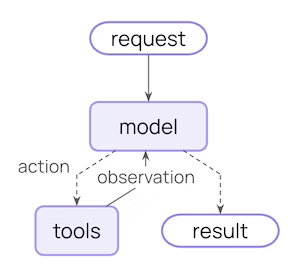

Middleware exposes hooks before and after each of those steps:

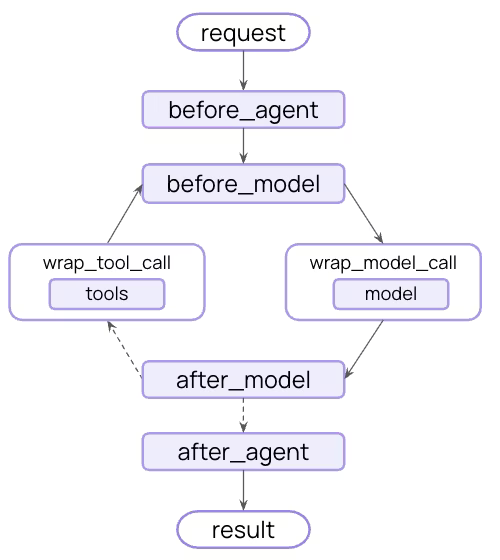

### Use middleware inside a LangGraph workflow

Middleware is not a separate runtime: hooks run inside the compiled LangGraph that create_agent returns. You can drop the whole agent (middleware and all) into a larger StateGraph as a node or subgraph, and every middleware hook continues to run.

 Reach for this pattern when the surrounding topology is more than a standard “loop until done”: classifying input before routing to one of several agents, fanning out work in parallel, or stitching agent calls together with deterministic steps.
 
  HumanInTheLoopMiddleware matches against each tool’s .name. In Python, @tool-decorated functions take their name from the function (so the key below is "send_email"); in TypeScript, the key matches the name you pass to tool({...}, { name }).

In [ ]:
from langchain.agents import AgentState, create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.graph import START, StateGraph

# Assumes read_email, send_email, classify_node, and route are defined elsewhere.
email_agent = create_agent(
    model,
    tools=[read_email, send_email],
    middleware=[HumanInTheLoopMiddleware(interrupt_on={"send_email": True})],
)

graph = (
    StateGraph(AgentState)
    .add_node("classify", classify_node)
    .add_node("email_agent", email_agent)
    .add_edge(START, "classify")
    .add_conditional_edges("classify", route)
    .compile()
)

In [ ]:
from pydantic import BaseModel, Field
from langchain.tools import tool
from langchain.agents import AgentState, create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.graph import START, StateGraph
from langchain_openai import ChatOpenAI
import os

# ============= EMAIL TOOLS =============

class ReadEmailInput(BaseModel):
    email_id: str = Field(description="The unique email ID to read")
    mailbox: str = Field(default="inbox", description="Mailbox to read from (inbox, sent, drafts)")

@tool(args_schema=ReadEmailInput, description="Read and retrieve email content by ID.")
def read_email(email_id: str, mailbox: str = "inbox") -> str:
    """Read email from specified mailbox."""
    emails = {
        "email_001": {
            "from": "client@example.com",
            "subject": "Project Update Needed",
            "body": "Can you provide an update on the Q4 project status?",
            "timestamp": "2025-05-21 10:30"
        },
        "email_002": {
            "from": "manager@example.com",
            "subject": "Meeting Tomorrow",
            "body": "Please confirm attendance for tomorrow's 2 PM meeting.",
            "timestamp": "2025-05-21 09:15"
        },
        "email_003": {
            "from": "support@example.com",
            "subject": "Account Verification",
            "body": "Click here to verify your account.",
            "timestamp": "2025-05-21 08:00"
        }
    }
    
    if email_id in emails:
        email = emails[email_id]
        return f"From: {email['from']}\nSubject: {email['subject']}\nTime: {email['timestamp']}\n\nBody:\n{email['body']}"
    return f"Email {email_id} not found in {mailbox}."

class SendEmailInput(BaseModel):
    recipient: str = Field(description="Email address of the recipient")
    subject: str = Field(description="Email subject line")
    body: str = Field(description="Email body content")
    priority: str = Field(default="normal", description="Email priority (low, normal, high)")

@tool(args_schema=SendEmailInput, description="Send an email to a recipient.")
def send_email(recipient: str, subject: str, body: str, priority: str = "normal") -> str:
    """Send an email with specified content."""
    return f"✓ Email sent successfully\nTo: {recipient}\nSubject: {subject}\nPriority: {priority}\nStatus: Delivered"

# ============= CUSTOM STATE CLASS =============

class EmailAgentState(AgentState):
    classification: str = ""

# ============= CLASSIFICATION NODE =============

def classify_node(state: EmailAgentState) -> dict:
    """Classify incoming user request to route to appropriate handler."""
    
    model = ChatOpenAI(
        model="gpt-5-mini",
        api_key=os.getenv("API_KEY"),
        base_url=os.getenv("BASE_URL"),
    )
    
    messages = state.get("messages", [])
    if not messages:
        return {"classification": "unknown"}
    
    last_message = messages[-1]
    user_input = last_message.content if hasattr(last_message, 'content') else str(last_message)
    
    classification_prompt = f"""Classify this user request into ONE of these categories:
    - "read_email": User wants to read or check emails
    - "send_email": User wants to send an email or compose a message
    - "general": General inquiry or conversation
    
    User request: {user_input}
    
    Respond with ONLY the category name, nothing else."""
    
    response = model.invoke([{"role": "user", "content": classification_prompt}])
    classification = response.content.strip().lower()
    
    valid_classifications = ["read_email", "send_email", "general"]
    if not any(cat in classification for cat in valid_classifications):
        classification = "general"
    
    return {"classification": classification}

# ============= ROUTING FUNCTION =============

def route(state: EmailAgentState) -> str:
    """Route to email_agent or end based on classification."""
    
    classification = state.get("classification", "general").lower()
    
    if "read_email" in classification or "send_email" in classification:
        return "email_agent"
    else:
        return "__end__"

# ============= MAIN WORKFLOW =============

model = ChatOpenAI(
    model="gpt-5-mini",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
)

# Create email agent with tools
email_agent = create_agent(
    model,
    tools=[read_email, send_email],
    middleware=[HumanInTheLoopMiddleware(interrupt_on={"send_email": True})],
)

# Build routing graph
graph = (
    StateGraph(EmailAgentState)
    .add_node("classify", classify_node)
    .add_node("email_agent", email_agent)
    .add_edge(START, "classify")
    .add_conditional_edges("classify", route, {"email_agent": "email_agent", "__end__": "__end__"})
    .compile()
)

# Test the workflow
result = graph.invoke({
    "messages": [{"role": "user", "content": "Can you read my emails and , give me all summary for email_001 found  in inbox and send a reply?"}]
})

for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Can you read my emails and , give me all summary for email_001 found  in inbox and send a reply?
================================== Ai Message ==================================
Tool Calls:
  read_email (call_hTkZr7upe500PCDmH9IsNoDT)
 Call ID: call_hTkZr7upe500PCDmH9IsNoDT
  Args:
    email_id: email_001
    mailbox: inbox
================================= Tool Message =================================
Name: read_email

From: client@example.com
Subject: Project Update Needed
Time: 2025-05-21 10:30

Body:
Can you provide an update on the Q4 project status?
================================== Ai Message ==================================

I read email_001 in your inbox. Summary and a suggested reply are below.

Summary of email_001:
- From: client@example.com
- Subject: Project Update Needed
- Received: 2025-05-21 10:30
- Body: The sender asks for an update on the Q4 project status.

Suggested reply (ready 

### Prebuilt middleware

#### Summarization

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:

    Long-running conversations that exceed context windows.
    Multi-turn dialogues with extensive history.
    Applications where preserving full conversation context matters.


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
# from langchain.chat_models import init_chat_model

# custom_profile = {
#     "max_input_tokens": 100_000,
#     # ...
# }
# model = init_chat_model("gpt-5.4", profile=custom_profile)
agent = create_agent(
    model="gpt-5.4",
    tools=[your_weather_tool, your_calculator_tool],
    middleware=[
        SummarizationMiddleware(
            model="gpt-5-mini",
            trigger=("tokens", 4000),
            keep=("messages", 20),
        ),
    ],
)

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware


# Single condition: trigger if tokens >= 4000
agent = create_agent(
    model="gpt-5.4",
    tools=[your_weather_tool, your_calculator_tool],
    middleware=[
        SummarizationMiddleware(
            model="gpt-5.4-mini",
            trigger=("tokens", 4000),
            keep=("messages", 20),
        ),
    ],
)

# Multiple conditions: trigger if number of tokens >= 3000 OR messages >= 6
agent2 = create_agent(
    model="gpt-5.4",
    tools=[your_weather_tool, your_calculator_tool],
    middleware=[
        SummarizationMiddleware(
            model="gpt-5.4-mini",
            trigger=[
                ("tokens", 3000),
                ("messages", 6),
            ],
            keep=("messages", 20),
        ),
    ],
)

# Using fractional limits
agent3 = create_agent(
    model="gpt-5.4",
    tools=[your_weather_tool, your_calculator_tool],
    middleware=[
        SummarizationMiddleware(
            model="gpt-5.4-mini",
            trigger=("fraction", 0.8),
            keep=("fraction", 0.3),
        ),
    ],
)

#### Human-in-the-loop

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:

    High-stakes operations requiring human approval (e.g. database writes, financial transactions).
    Compliance workflows where human oversight is mandatory.
    Long-running conversations where human feedback guides the agent.


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def your_read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def your_send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model,
    tools=[your_read_email_tool, your_send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "your_send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "your_read_email_tool": False,
            }
        ),
    ],
)
config = {"configurable": {"thread_id": "some_id"}}

res = agent.invoke(
    {"messages": [{"role": "user", "content": "read my email and send mail"}]},
    config=config,
)
for msg in res["messages"]:
    msg.pretty_print()

================================ Human Message =================================

read my email and send mail
================================== Ai Message ==================================
Tool Calls:
  your_read_email_tool (call_NODiIyubasq2be21icTLOHyb)
 Call ID: call_NODiIyubasq2be21icTLOHyb
  Args:
    email_id: inbox:latest
================================= Tool Message =================================
Name: your_read_email_tool

Email content for ID: inbox:latest
================================== Ai Message ==================================
Tool Calls:
  your_read_email_tool (call_V57vQxtljskNo1a9pGxyGCQH)
 Call ID: call_V57vQxtljskNo1a9pGxyGCQH
  Args:
    email_id: inbox:latest
================================= Tool Message =================================
Name: your_read_email_tool

Email content for ID: inbox:latest
================================== Ai Message ==================================

I attempted to read your latest email but the tool returned only a placeho

#### Model call limit

Limit the number of model calls to prevent infinite loops or excessive costs. Model call limit is useful for the following:

    Preventing runaway agents from making too many API calls.
    Enforcing cost controls on production deployments.
    Testing agent behavior within specific call budgets.


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    model,
    checkpointer=InMemorySaver(),  # Required for thread limiting
    tools=[],
    middleware=[
        ModelCallLimitMiddleware(
            thread_limit=10,
            run_limit=5,
            exit_behavior="end",
        ),
    ],
)

#### Tool call limit

Control agent execution by limiting the number of tool calls, either globally across all tools or for specific tools. Tool call limits are useful for the following:

    Preventing excessive calls to expensive external APIs.
    Limiting web searches or database queries.
    Enforcing rate limits on specific tool usage.
    Protecting against runaway agent loops.


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware

agent = create_agent(
    model,
    tools=[search_tool, database_tool],
    middleware=[
        # Global limit
        ToolCallLimitMiddleware(thread_limit=20, run_limit=10),
        # Tool-specific limit
        ToolCallLimitMiddleware(
            tool_name="search",
            thread_limit=5,
            run_limit=3,
        ),
    ],
)

#### Model fallback

Automatically fallback to alternative models when the primary model fails. Model fallback is useful for the following:

    Building resilient agents that handle model outages.
    Cost optimization by falling back to cheaper models.
    Provider redundancy across OpenAI, Anthropic, etc.


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelFallbackMiddleware

agent = create_agent(
    model="gpt-5.4",
    tools=[],
    middleware=[
        ModelFallbackMiddleware(
            "gpt-5.4-mini",
            "claude-3-5-sonnet-20241022",
        ),
    ],
)

#### PII detection

Detect and handle Personally Identifiable Information (PII) in conversations using configurable strategies. PII detection is useful for the following:

    Healthcare and financial applications with compliance requirements.
    Customer service agents that need to sanitize logs.
    Any application handling sensitive user data.


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware

agent = create_agent(
    model="gpt-5.4",
    tools=[],
    middleware=[
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),
    ],
)

#### Custom PII types

You can create custom PII types by providing a detector parameter. This allows you to detect patterns specific to your use case beyond the built-in types. Three ways to create custom detectors:

    Regex pattern string - Simple pattern matching
    Custom function - Complex detection logic with validation


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware
import re


# Method 1: Regex pattern string
agent1 = create_agent(
    model="gpt-5.4",
    tools=[],
    middleware=[
        PIIMiddleware(
            "api_key",
            detector=r"sk-[a-zA-Z0-9]{32}",
            strategy="block",
        ),
    ],
)

# Method 2: Compiled regex pattern
agent2 = create_agent(
    model="gpt-5.4",
    tools=[],
    middleware=[
        PIIMiddleware(
            "phone_number",
            detector=re.compile(r"\+?\d{1,3}[\s.-]?\d{3,4}[\s.-]?\d{4}"),
            strategy="mask",
        ),
    ],
)

# Method 3: Custom detector function
def detect_ssn(content: str) -> list[dict[str, str | int]]:
    """Detect SSN with validation.

    Returns a list of dictionaries with 'text', 'start', and 'end' keys.
    """
    import re
    matches = []
    pattern = r"\d{3}-\d{2}-\d{4}"
    for match in re.finditer(pattern, content):
        ssn = match.group(0)
        # Validate: first 3 digits shouldn't be 000, 666, or 900-999
        first_three = int(ssn[:3])
        if first_three not in [0, 666] and not (900 <= first_three <= 999):
            matches.append({
                "text": ssn,
                "start": match.start(),
                "end": match.end(),
            })
    return matches

agent3 = create_agent(
    model="gpt-5.4",
    tools=[],
    middleware=[
        PIIMiddleware(
            "ssn",
            detector=detect_ssn,
            strategy="hash",
        ),
    ],
)

Custom detector function signature: The detector function must accept a string (content) and return matches: Returns a list of dictionaries with text, start, and end keys:

In [ ]:
def detector(content: str) -> list[dict[str, str | int]]:
    return [
        {"text": "matched_text", "start": 0, "end": 12},
        # ... more matches
    ]

#### To-do list

Equip agents with task planning and tracking capabilities for complex multi-step tasks. To-do lists are useful for the following:

    Complex multi-step tasks requiring coordination across multiple tools.
    Long-running operations where progress visibility is important.


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import TodoListMiddleware

agent = create_agent(
    model="gpt-5.4",
    tools=[read_file, write_file, run_tests],
    middleware=[TodoListMiddleware()],
)

#### LLM tool selector

Use an LLM to intelligently select relevant tools before calling the main model. LLM tool selectors are useful for the following:

    Agents with many tools (10+) where most aren’t relevant per query.
    Reducing token usage by filtering irrelevant tools.
    Improving model focus and accuracy.


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import LLMToolSelectorMiddleware

agent = create_agent(
    model="gpt-5.4",
    tools=[tool1, tool2, tool3, tool4, tool5, ...],
    middleware=[
        LLMToolSelectorMiddleware(
            model="gpt-5.4-mini",
            max_tools=3,
            always_include=["search"],
        ),
    ],
)

#### Tool retry

Automatically retry failed tool calls with configurable exponential backoff. Tool retry is useful for the following:

    Handling transient failures in external API calls.
    Improving reliability of network-dependent tools.
    Building resilient agents that gracefully handle temporary errors.


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import ToolRetryMiddleware

agent = create_agent(
    model="gpt-5.4",
    tools=[search_tool, database_tool],
    middleware=[
        ToolRetryMiddleware(
            max_retries=3,
            backoff_factor=2.0,
            initial_delay=1.0,
        ),
    ],
)

#### Model retry

Automatically retry failed model calls with configurable exponential backoff. Model retry is useful for the following:

    Handling transient failures in model API calls.
    Improving reliability of network-dependent model requests.
    Building resilient agents that gracefully handle temporary model errors.


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelRetryMiddleware

agent = create_agent(
    model,
    tools=[search_tool, database_tool],
    middleware=[
        ModelRetryMiddleware(
            max_retries=3,
            backoff_factor=2.0,
            initial_delay=1.0,
        ),
    ],
)

#### LLM tool emulator

In [10]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
load_dotenv()

model = ChatOpenAI(model='gpt-3.5-turbo', 
                   api_key=os.getenv("API_KEY"),
                   base_url=os.getenv("BASE_URL"),
                   )


In [11]:
from langchain.agents import create_agent
from langchain.agents.middleware import LLMToolEmulator
from langchain.tools import tool


@tool
def get_weather(location: str) -> str:
    """Get the current weather for a location."""
    return f"Weather in {location}"

@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email."""
    return "Email sent"


# Emulate all tools (default behavior)
agent = create_agent(
    model,
    tools=[get_weather, send_email],
    middleware=[LLMToolEmulator(model=model)],
)

# Emulate specific tools only
agent2 = create_agent(
    model,
    tools=[get_weather, send_email],
    middleware=[LLMToolEmulator(tools=["get_weather"],model=model)],
)

# # Use custom model for emulation
# agent4 = create_agent(
#     model,
#     tools=[get_weather, send_email],
#     middleware=[LLMToolEmulator(model="claude-sonnet-4-6")],
# )

In [12]:
res=agent.invoke({
    "messages": [
        {"role": "user", "content": "what is the weather right now in india and send it as email to my friend dev"}
    ]
})
for msg in res["messages"]:
    msg.pretty_print()

================================ Human Message =================================

what is the weather right now in india and send it as email to my friend dev
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_ASsVd0m5GjZ2tEiG67bh9Yaa)
 Call ID: call_ASsVd0m5GjZ2tEiG67bh9Yaa
  Args:
    location: India
================================= Tool Message =================================
Name: get_weather

{"location": "India", "temperature": "31°C", "condition": "Partly Cloudy", "humidity": "60%", "wind_speed": "15 km/h", "forecast": "Little to no chance of rain today."}
================================== Ai Message ==================================
Tool Calls:
  send_email (call_JFVto4FmOMsmbAyYebE0J6GL)
 Call ID: call_JFVto4FmOMsmbAyYebE0J6GL
  Args:
    body: Hello Dev,

The current weather in India is as follows:
- Temperature: 31°C
- Condition: Partly Cloudy
- Humidity: 60%
- Wind Speed: 15 km/h
- Forecast: Little to no cha

#### Context editing

Manage conversation context by clearing older tool call outputs when token limits are reached, while preserving recent results. This helps keep context windows manageable in long conversations with many tool calls. Context editing is useful for the following:

    Long conversations with many tool calls that exceed token limits
    Reducing token costs by removing older tool outputs that are no longer relevant
    Maintaining only the most recent N tool results in context


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import ContextEditingMiddleware, ClearToolUsesEdit

agent = create_agent(
    model="gpt-5.4",
    tools=[],
    middleware=[
        ContextEditingMiddleware(
            edits=[
                ClearToolUsesEdit(
                    trigger=100000,
                    keep=3,
                ),
            ],
        ),
    ],
)

#### Shell tool

Expose a persistent shell session to agents for command execution. Shell tool middleware is useful for the following:

    Agents that need to execute system commands
    Development and deployment automation tasks
    Testing and validation workflows
    File system operations and script execution


In [25]:
from langchain.agents import create_agent
from langchain.agents.middleware import (
    ShellToolMiddleware,
    HostExecutionPolicy,
)
from pydantic import BaseModel, Field
class SearchToolInput(BaseModel):
    query: str = Field(description="Search query")
    limit: int = Field(default=10, description="Maximum number of results to return")

@tool(args_schema=SearchToolInput, description="Search the database for matching records.")
def search_tool(query: str, limit: int = 10) -> str:
    return f"Found up to {limit} results for '{query}'."
agent = create_agent(
    model,
    tools=[search_tool],
    middleware=[
        ShellToolMiddleware(
            # workspace_root="/home/harsh.dhandha@simform.dom/hh/GenAI/campusx",
            workspace_root="/home/harsh.dhandha@simform.dom/hh/GenAI/langchain",
            execution_policy=HostExecutionPolicy(),
        ),
    ],
)
res = agent.invoke({
    "messages": [
        {"role": "user", "content": "search the workspace for all files and list the files/folders"}
    ]
})

for msg in res["messages"]:
    msg.pretty_print()

================================ Human Message =================================

search the workspace for all files and list the files/folders
================================== Ai Message ==================================
Tool Calls:
  shell (call_hcHSqqsLEvmUBMixSvmNQGCG)
 Call ID: call_hcHSqqsLEvmUBMixSvmNQGCG
  Args:
    command: ls -al
================================= Tool Message =================================
Name: shell

total 828
drwxr-xr-x  3 harsh.dhandha@simform.dom domain users@simform.dom   4096 May 22 15:09 .
drwxr-xr-x 10 harsh.dhandha@simform.dom domain users@simform.dom   4096 May 22 15:16 ..
-rw-r--r--  1 harsh.dhandha@simform.dom domain users@simform.dom  15212 May 13 12:10 URL_fetch_agent.ipynb
-rw-r--r--  1 harsh.dhandha@simform.dom domain users@simform.dom   1292 May 13 14:56 agent_with_tool.py
-rw-r--r--  1 harsh.dhandha@simform.dom domain users@simform.dom 782316 May 22 15:19 docs.ipynb
-rw-r--r--  1 harsh.dhandha@simform.dom domain users@simform.dom    6

#### File search

Provide Glob and Grep search tools over a filesystem. File search middleware is useful for the following:

    Code exploration and analysis
    Finding files by name patterns
    Searching code content with regex
    Large codebases where file discovery is needed


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import FilesystemFileSearchMiddleware

agent = create_agent(
    model,
    tools=[],
    middleware=[
        FilesystemFileSearchMiddleware(
            root_path="/workspace",
            use_ripgrep=True,
        ),
    ],
)

#### Filesystem middleware

Context engineering is a main challenge in building effective agents. This is particularly difficult when using tools that return variable-length results (for example, web_search and RAG), as long tool results can quickly fill your context window. FilesystemMiddleware from Deep Agents provides four tools for interacting with both short-term and long-term memory:

    ls: List the files in the filesystem
    read_file: Read an entire file or a certain number of lines from a file
    write_file: Write a new file to the filesystem
    edit_file: Edit an existing file in the filesystem


In [ ]:
from langchain.agents import create_agent
from deepagents.middleware.filesystem import FilesystemMiddleware

# FilesystemMiddleware is included by default in create_deep_agent
# You can customize it if building a custom agent
agent = create_agent(
    model="claude-sonnet-4-6",
    middleware=[
        FilesystemMiddleware(
            backend=None,  # Optional: custom backend (defaults to StateBackend)
            system_prompt="Write to the filesystem when...",  # Optional custom addition to the system prompt
            custom_tool_descriptions={
                "ls": "Use the ls tool when...",
                "read_file": "Use the read_file tool to..."
            }  # Optional: Custom descriptions for filesystem tools
        ),
    ],
)

#### Short-term vs. long-term filesystem

In [ ]:
from langchain.agents import create_agent
from deepagents.middleware import FilesystemMiddleware
from deepagents.backends import CompositeBackend, StateBackend, StoreBackend
from langgraph.store.memory import InMemoryStore

store = InMemoryStore()

agent = create_agent(
    model="claude-sonnet-4-6",
    store=store,
    middleware=[
        FilesystemMiddleware(
            backend=CompositeBackend(
                default=StateBackend(),
                routes={"/memories/": StoreBackend()}
            ),
            custom_tool_descriptions={
                "ls": "Use the ls tool when...",
                "read_file": "Use the read_file tool to..."
            }  # Optional: Custom descriptions for filesystem tools
        ),
    ],
)

When you configure a CompositeBackend with a StoreBackend for /memories/, any files prefixed with /memories/ are saved to persistent storage and survive across different threads. Files without this prefix remain in ephemeral state storage.

#### Subagent

Handing off tasks to subagents isolates context, keeping the main (supervisor) agent’s context window clean while still going deep on a task.

The subagents middleware from Deep Agents allows you to supply subagents through a task tool.

In [ ]:
from langchain.tools import tool
from langchain.agents import create_agent
from deepagents.middleware.subagents import SubAgentMiddleware


@tool
def get_weather(city: str) -> str:
    """Get the weather in a city."""
    return f"The weather in {city} is sunny."

agent = create_agent(
    model="claude-sonnet-4-6",
    middleware=[
        SubAgentMiddleware(
            default_model="claude-sonnet-4-6",
            default_tools=[],
            subagents=[
                {
                    "name": "weather",
                    "description": "This subagent can get weather in cities.",
                    "system_prompt": "Use the get_weather tool to get the weather in a city.",
                    "tools": [get_weather],
                    "model": "gpt-5.4",
                    "middleware": [],
                }
            ],
        )
    ],
)

A subagent is defined with a name, description, system prompt, and tools. You can also provide a subagent with a custom model, or with additional middleware. This can be particularly useful when you want to give the subagent an additional state key to share with the main agent.

For more complex use cases, you can also provide your own prebuilt LangGraph graph as a subagent.

In [ ]:
from langchain.agents import create_agent
from deepagents.middleware.subagents import SubAgentMiddleware
from deepagents import CompiledSubAgent
from langgraph.graph import StateGraph

# Create a custom LangGraph graph
def create_weather_graph():
    workflow = StateGraph(...)
    # Build your custom graph
    return workflow.compile()

weather_graph = create_weather_graph()

# Wrap it in a CompiledSubAgent
weather_subagent = CompiledSubAgent(
    name="weather",
    description="This subagent can get weather in cities.",
    runnable=weather_graph
)

agent = create_agent(
    model="claude-sonnet-4-6",
    middleware=[
        SubAgentMiddleware(
            default_model="claude-sonnet-4-6",
            default_tools=[],
            subagents=[weather_subagent],
        )
    ],
)

### Custom Middleware
#### Hooks
Middleware provides two styles of hooks to intercept agent execution:
- Node-style hooks
Run sequentially at specific execution points.
- Wrap-style hooks
Run around each model or tool call.

Node-style hooks
Run sequentially at specific execution points. Use for logging, validation, and state updates. Choose the hooks your middleware needs. You can choose between node-style hooks and wrap-style hooks.

Node-style hooks run at specific execution points:
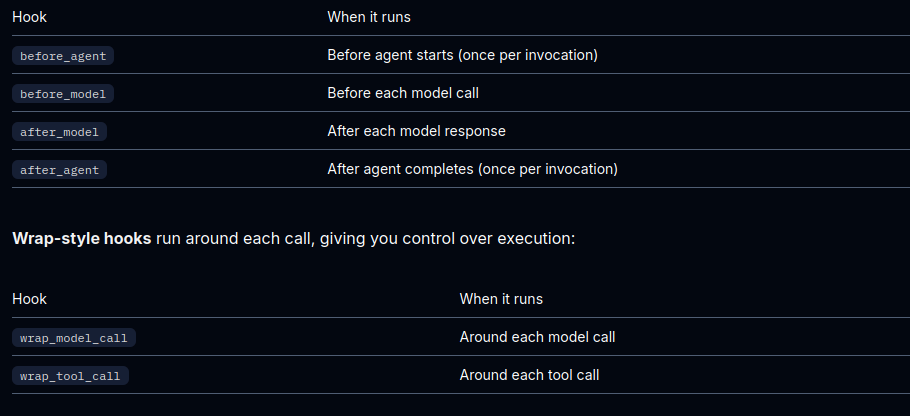

In [ ]:
from langchain.agents.middleware import before_model, after_model, AgentState
from langchain.messages import AIMessage
from langgraph.runtime import Runtime
from typing import Any


@before_model(can_jump_to=["end"])
def check_message_limit(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    if len(state["messages"]) >= 50:
        return {
            "messages": [AIMessage("Conversation limit reached.")],
            "jump_to": "end"
        }
    return None

@after_model
def log_response(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print(f"Model returned: {state['messages'][-1].content}")
    return None

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable


@wrap_model_call
def retry_model(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    for attempt in range(3):
        try:
            return handler(request)
        except Exception as e:
            if attempt == 2:
                raise
            print(f"Retry {attempt + 1}/3 after error: {e}")

#### State updates

Both node-style and wrap-style hooks can update agent state. The mechanism differs:

    Node-style hooks (before_agent, before_model, after_model, after_agent): Return a dict directly. The dict is applied to the agent state using the graph’s reducers.
    
    Wrap-style hooks (wrap_model_call, wrap_tool_call): For model calls, return ExtendedModelResponse with a Command to inject state updates alongside the model response. For tool calls, return a Command directly. Use these when you need to track or update state based on logic that runs during the model or tool call, such as summarization trigger points, usage metadata, or custom fields calculated from the request or response.


Node-style hooks

In [ ]:
from langchain.agents.middleware import after_model, AgentState
from langgraph.runtime import Runtime
from typing import Any
from typing_extensions import NotRequired


class TrackingState(AgentState):
    model_call_count: NotRequired[int]


@after_model(state_schema=TrackingState)
def increment_after_model(state: TrackingState, runtime: Runtime) -> dict[str, Any] | None:
    return {"model_call_count": state.get("model_call_count", 0) + 1}

Wrap-style hooks

In [ ]:
from typing import Callable
from langchain.agents.middleware import (
    wrap_model_call,
    ModelRequest,
    ModelResponse,
    AgentState,
    ExtendedModelResponse
)
from langgraph.types import Command
from typing_extensions import NotRequired

class UsageTrackingState(AgentState):
    """Agent state with token usage tracking."""

    last_model_call_tokens: NotRequired[int]


@wrap_model_call(state_schema=UsageTrackingState)
def track_usage(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ExtendedModelResponse:
    response = handler(request)
    return ExtendedModelResponse(
        model_response=response,
        command=Command(update={"last_model_call_tokens": 150}),
    )

## Retrival

Large Language Models (LLMs) are powerful, but they have two key limitations:

    Finite context—they can’t ingest entire corpora at once.
    Static knowledge—their training data is frozen at a point in time.

Retrieval addresses these problems by fetching relevant external knowledge at query time. This is the foundation of Retrieval-Augmented Generation (RAG): enhancing an LLM’s answers with context-specific information.

### Retrieval pipeline

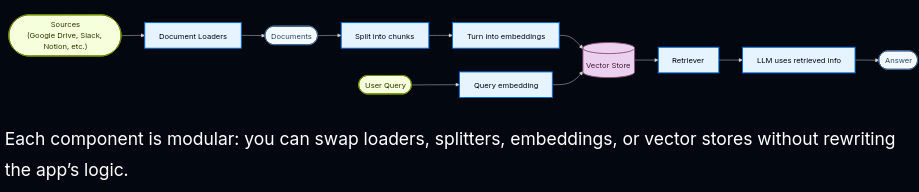

microsoft/harrier-oss-v1-270m embedding

In [ ]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="hf-inference",
    api_key=os.environ["HF_TOKEN"],
)

result = client.feature_extraction(
    "Today is a sunny day and I will get some ice cream.",
    model="microsoft/harrier-oss-v1-270m",
)

BadRequestError: (Request ID: Root=1-6a103bf9-360b8aa10574124c6484bcf6;bf3134c8-3207-452e-8d4c-efef13bcac91)

Bad request:
Model not supported by provider hf-inference

In [29]:
print(result)

[-5.68665825e-02 -5.35304584e-02 -1.17905706e-03 -8.11727792e-02
  1.68764461e-02  1.91016831e-02 -4.64509577e-02  9.06689186e-03
 -2.89284112e-03  2.15507057e-02 -3.74098383e-02 -1.10768224e-03
  9.95012093e-03  1.59441736e-02 -8.81294608e-02  2.71545798e-02
 -1.92044694e-02  1.49444286e-02 -1.09841274e-02 -7.53727183e-03
 -4.60474007e-03  5.35234399e-02 -3.30880168e-03 -3.50103416e-02
 -5.15983514e-02 -3.71327437e-02 -3.10182720e-02 -5.70905916e-02
 -1.35245904e-01 -2.23569758e-02  2.08711326e-02 -2.99077872e-02
 -3.81723270e-02 -1.51353329e-02  3.36470753e-02 -2.38228347e-02
 -1.82830095e-02 -1.59242935e-02  3.29402648e-02 -5.68685718e-02
 -1.04288375e-02  2.17767470e-02  1.88274849e-02 -1.39305368e-03
  2.58561242e-02  5.10765649e-02 -2.43761986e-02  8.24868027e-03
  4.98296618e-02  3.01133022e-02 -7.39429072e-02  1.60961889e-03
  3.04455422e-02  1.11289695e-01  6.37154281e-02 -7.70210475e-03
  4.03456651e-02  2.06927978e-03  6.74522528e-03  3.26943956e-02
 -1.00628557e-02  1.49418

### RAG architectures

RAG can be implemented in multiple ways, depending on your system’s needs. We outline each type in the sections below.

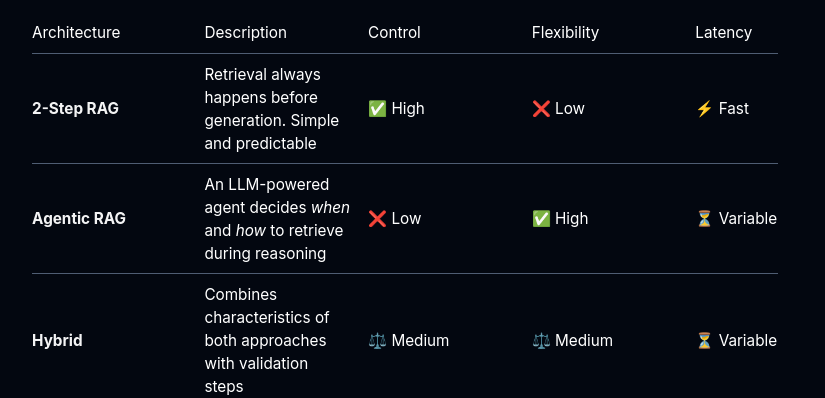

### 2-step RAG
In 2-Step RAG, the retrieval step is always executed before the generation step. This architecture is straightforward and predictable, making it suitable for many applications where the retrieval of relevant documents is a clear prerequisite for generating an answer.

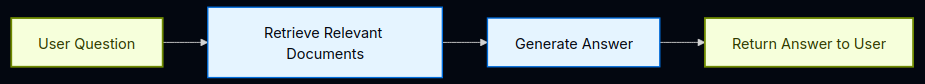

### Agentic RAG

Agentic Retrieval-Augmented Generation (RAG) combines the strengths of Retrieval-Augmented Generation with agent-based reasoning. Instead of retrieving documents before answering, an agent (powered by an LLM) reasons step-by-step and decides when and how to retrieve information during the interaction.
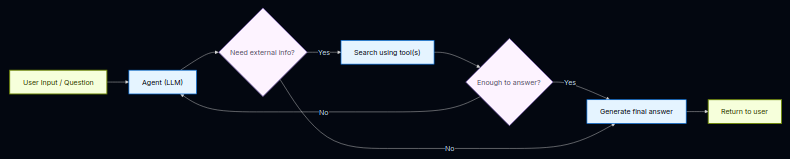

In [2]:
import requests
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain_openrouter import ChatOpenRouter

@tool
def fetch_url(url: str) -> str:
    """Fetch text content from a URL"""
    response = requests.get(url, timeout=10.0)
    response.raise_for_status()
    return response.text

system_prompt = """\
Use fetch_url when you need to fetch information from a web-page; quote relevant snippets.
"""
model = ChatOpenRouter(
    model = "openai/gpt-oss-20b",

)
agent = create_agent(
    model,
    tools=[fetch_url], # A tool for retrieval
    system_prompt=system_prompt,
)

res= agent.invoke({"messages" :[{"role": "user","content":"This is the url -https://docs.chonkie.ai/oss/chunkers/overview, and tell me a summary about it"}
                    ]
                   })
for msg in res["messages"]:
    msg.pretty_print()

BadRequestResponseError: This endpoint's maximum context length is 131072 tokens. However, you requested about 244080 tokens (244022 of text input, 58 of tool input). Please reduce the length of either one, or use the context-compression plugin to compress your prompt automatically.

### Hybrid RAG
Hybrid RAG combines characteristics of both 2-Step and Agentic RAG. It introduces intermediate steps such as query preprocessing, retrieval validation, and post-generation checks. These systems offer more flexibility than fixed pipelines while maintaining some control over execution.

Typical components include:

- Query enhancement: Modify the input question to improve retrieval quality. This can involve rewriting unclear queries, generating multiple variations, or expanding queries with additional context.
- Retrieval validation: Evaluate whether retrieved documents are relevant and sufficient. If not, the system may refine the query and retrieve again.
- Answer validation: Check the generated answer for accuracy, completeness, and alignment with source content. If needed, the system can regenerate or revise the answer.

## Caching
Embeddings can be stored or temporarily cached to avoid needing to recompute them. 

Caching embeddings can be done using a CacheBackedEmbeddings. This wrapper stores embeddings in a key-value store, where the text is hashed and the hash is used as the key in the cache.

The main supported way to initialize a CacheBackedEmbeddings is from_bytes_store. It takes the following parameters:

`- underlying_embedder: The embedder to use for embedding.
- document_embedding_cache: Any ByteStore for caching document embeddings.
- batch_size: (optional, defaults to None) The number of documents to embed between store updates.
- namespace: (optional, defaults to "") The namespace to use for the document cache. Helps avoid collisions (e.g., set it to the embedding model name).
- query_embedding_cache: (optional, defaults to None) A ByteStore for caching query embeddings, or True to reuse the same store as document_embedding_cache.`

In [31]:
import time
from langchain_classic.embeddings import CacheBackedEmbeddings  
from langchain_classic.storage import LocalFileStore 
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings

# Create your underlying embeddings model
underlying_embeddings = OpenAIEmbeddings(
        model="text-embedding-3-small",
        api_key=os.getenv("API_KEY"),
        base_url=os.getenv("BASE_URL"),
    ) # e.g., OpenAIEmbeddings(), HuggingFaceEmbeddings(), etc.

# Store persists embeddings to the local filesystem
# This isn't for production use, but is useful for local
store = LocalFileStore("./cache/")

cached_embedder = CacheBackedEmbeddings.from_bytes_store(
    underlying_embeddings,
    store,
    namespace=underlying_embeddings.model
)

# Example: caching a query embedding
tic = time.time()
print(cached_embedder.embed_query("Hello, world!"))
print(f"First call took: {time.time() - tic:.2f} seconds")

# Subsequent calls use the cache
tic = time.time()
print(cached_embedder.embed_query("Hello, world!"))
print(f"Second call took: {time.time() - tic:.2f} seconds")

/home/harsh.dhandha@simform.dom/hh/GenAI/.venv/lib/python3.12/site-packages/langchain_classic/embeddings/cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. While acceptable for most cache scenarios, a motivated attacker can craft two different payloads that map to the same cache key. If that risk matters in your environment, supply a stronger encoder (e.g. SHA-256 or BLAKE2) via the `key_encoder` argument. If you change the key encoder, consider also creating a new cache, to avoid (the potential for) collisions with existing keys.
  _warn_about_sha1_encoder()


[-0.0191497802734375, -0.0251922607421875, -0.0017795562744140625, 0.018829345703125, -0.033843994140625, -0.0197296142578125, -0.02093505859375, 0.051544189453125, -0.0321044921875, -0.0304107666015625, -0.002140045166015625, -0.028961181640625, -0.002445220947265625, -0.031494140625, 0.01030731201171875, 0.0185699462890625, -0.046142578125, 0.04144287109375, 0.00042366981506347656, 0.04119873046875, 0.053619384765625, 0.00183868408203125, 0.004547119140625, 0.00997161865234375, 0.04779052734375, 0.002185821533203125, -0.00982666015625, 0.0384521484375, 0.0008525848388671875, -0.052093505859375, 0.051116943359375, -0.032501220703125, -0.01399993896484375, -0.0126190185546875, 0.0133209228515625, 0.018585205078125, 0.001628875732421875, -0.00087738037109375, -0.01276397705078125, -0.029693603515625, -0.004486083984375, -0.0153045654296875, 0.025634765625, 0.0090484619140625, -0.03680419921875, 0.0202789306640625, -0.04071044921875, -0.0026073455810546875, 0.0355224609375, 0.04849243164